In [1]:
# ===== BASIC LIBRARIES =====
import numpy as np                  
import pandas as pd                
import matplotlib.pyplot as plt     
%matplotlib inline
import io                           
import os                           
import random
import seaborn as sns               

# ===== IMAGE PROCESSING =====
import cv2                          
from PIL import Image                   
from skimage.feature import hog     
from skimage.color import rgb2gray  
from io import BytesIO              

# ===== MACHINE LEARNING - SCIKIT-LEARN =====
# Base classes
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Model selection and evaluation
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ===== CLASSIFIERS =====
# Traditional ML classifiers
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# ===== DEEP LEARNING - TENSORFLOW/KERAS =====
import tensorflow as tf
import tensorflow.keras as keras

# Keras models
from tensorflow.keras.models import Sequential, model_from_json

# Keras layers
from tensorflow.keras.layers import (
    Dense, Flatten, Dropout, Activation, BatchNormalization,
    Conv2D, MaxPooling2D, MaxPool2D, Lambda, Input,
    PReLU, LeakyReLU
)

# Keras regularization
from tensorflow.keras.regularizers import l2

# ===== VISUALIZATION UTILITIES =====
from IPython.display import clear_output
from matplotlib.ticker import MaxNLocator

# ===== MISCELLANEOUS =====
from urllib import request      # Module for opening HTTP requests
import pickle                   # Object serialization
import sklearn as skl           # General sklearn import

KUL H02A5a Computer Vision: Group Assignment 1
---------------------------------------------------------------
Student numbers: <span style="color:red">r1065899, r1066163, r1065787, r1066641, r1066169</span>.

The goal of this assignment is to explore more advanced techniques for constructing features that better describe objects of interest and to perform face recognition using these features. This assignment will be delivered in groups of 5 (either composed by you or randomly assigned by your TA's).

In this assignment you are a group of computer vision experts that have been invited to ECCV 2025 to do a tutorial about  "Feature representations, then and now". To prepare the tutorial you are asked to participate in a kaggle competition and to release a notebook that can be easily studied by the tutorial participants. Your target audience is: (master) students who want to get a first hands-on introduction to the techniques that you apply.

---------------------------------------------------------------
This notebook is structured as follows:
0. Data loading & Preprocessing
1. Feature Representations
2. Evaluation Metrics 
3. Classifiers
4. Experiments
5. Publishing best results
6. Discussion

Make sure that your notebook is **self-contained** and **fully documented**. Walk us through all steps of your code. Treat your notebook as a tutorial for students who need to get a first hands-on introduction to the techniques that you apply. Provide strong arguments for the design choices that you made and what insights you got from your experiments. Make use of the *Group assignment* forum/discussion board on Toledo if you have any questions.

Fill in your student numbers above and get to it! Good luck! 


<div class="alert alert-block alert-info">
<b>NOTE:</b> This notebook is just a example/template, feel free to adjust in any way you please! Just keep things organised and document accordingly!
</div>

<div class="alert alert-block alert-info">
<b>NOTE:</b> Clearly indicate the improvements that you make!!! You can for instance use titles like: <i>3.1. Improvement: Non-linear SVM with RBF Kernel.<i>
</div>
    
---------------------------------------------------------------


# 0. Data loading & Preprocessing

## 0.1. Loading data
The training set is many times smaller than the test set and this might strike you as odd, however, this is close to a real world scenario where your system might be put through daily use! In this session we will try to do the best we can with the data that we've got! 

In [2]:
# Input data files are available in the read-only "../input/" directory

train = pd.read_csv(
    './kaggle/input/kul-computer-vision-ga-1-2025/train_set.csv', index_col = 0)
train.index = train.index.rename('id')

test = pd.read_csv(
    './kaggle/input/kul-computer-vision-ga-1-2025/test_set.csv', index_col = 0)
test.index = test.index.rename('id')

# read the images as numpy arrays and store in "img" column
train['img'] = [cv2.cvtColor(np.load('./kaggle/input/kul-computer-vision-ga-1-2025/train/train_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in train.iterrows()]

test['img'] = [cv2.cvtColor(np.load('./kaggle/input/kul-computer-vision-ga-1-2025/test/test_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in test.iterrows()]
  

train_size, test_size = len(train),len(test)

"The training set contains {} examples, the test set contains {} examples.".format(train_size, test_size)

'The training set contains 80 examples, the test set contains 1816 examples.'

## 0.1.1 Improvement: Data Augmentation
The provided training set contains only 80 data points. Working with small datasets presents significant challenges and could hinder the performance of our pipeline. 

Small datasets can't adequately capture the full range of variations present in the real world. For example, certain conditions, angles, lighting scenarios or facial expressions may be entirely missing.

This could lead to model overfitting, where our models memorise training examples rather than generalisable patterns.

Data Augmentation can help introduce variation in the data, which might be present in the test set but not in the training data. 

#### 1. Horizontal Flip
The addition of a horizontal flip immediately doubled our training set size from 80 to 160. This flip also introduced orientation variance, helping our model learn that the same identity can appear from different viewing angles. 

In [3]:
# 1. Horizontal flip
train_flipped = train.copy()

# Apply horizontal flip
train_flipped['img'] = [cv2.flip(img, 1) for img in train_flipped['img']]  # 1 means flipping around y-axis

# Add a suffix to the index to distinguish the flipped images
train_flipped.index = [f"{idx}_flipped" for idx in train_flipped.index]

# Combine the original and flipped datasets
train = pd.concat([train, train_flipped])

print(f"The augmented training set contains {len(train)} examples.")

The augmented training set contains 160 examples.


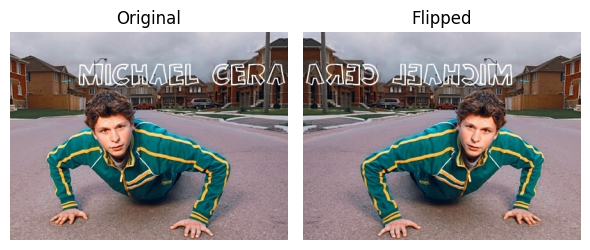

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))
ax1.imshow(train.iloc[4]['img'])
ax1.axis('off')
ax1.set_title('Original')
ax2.imshow(train_flipped.iloc[4]['img'])
ax2.axis('off')
ax2.set_title('Flipped')
plt.tight_layout()
plt.show()

#### 2. Random Rotations
Small rotations were used to again double our training set from 160 to 320. Rotations in the range of 5-15 degrees mimicked natural head tilts and simulated different camera angles. 

In [5]:
def random_rotation(image, min_angle=5, max_angle=15):

    # Determine the sign of the rotation (clockwise or counter-clockwise)
    sign = random.choice([-1, 1])
    
    # Generate a random angle between min_angle and max_angle
    angle = random.uniform(min_angle, max_angle) * sign
    
    # Get image dimensions
    height, width = image.shape[:2]
    
    # Calculate the rotation matrix
    center = (width // 2, height // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    
    # Apply the rotation
    rotated_image = cv2.warpAffine(image, rotation_matrix, (width, height), 
                                  flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, 
                                  borderValue=(0, 0, 0))
    
    return rotated_image

# 3. Flipped + Rotated
train_flipped_rotated = train.copy()
train_flipped_rotated['img'] = [random_rotation(img) for img in train_flipped_rotated['img']]

# Combine all datasets
train = pd.concat([train, train_flipped_rotated])

print(f"The augmented training set contains {len(train)} examples.")

The augmented training set contains 320 examples.


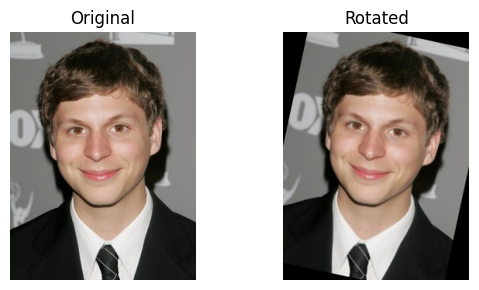

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))
ax1.imshow(train.iloc[2]['img'])
ax1.axis('off')
ax1.set_title('Original')
ax2.imshow(train_flipped_rotated.iloc[2]['img'])
ax2.axis('off')
ax2.set_title('Rotated')
plt.tight_layout()
plt.show()

#### Parameter Choice
It was important to keep our augmentations conservative. Through testing we found our dataset became too artificial and was no longer representative of unseen data. The parameters listed above were observed to provide the best results. 

In conjunction, these techniques were observed to improve our HOG feature extractor, and in turn our SVM and overall pipeline performance. 

*Note: this dataset is a subset of the* [*VGG face dataset*](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/).

## 0.2. A first look
Let's have a look at the data columns and class distribution.

In [7]:
# The training set contains an identifier, name, image information and class label
train.head(1)

,name,class,img
0,Mila_Kunis,2,"[[[50, 31, 25], [49, 30, 24], [49, 30, 24], [4..."


In [8]:
# The test set only contains an identifier and corresponding image information.
test.head(5)



,img
id,
0,"[[[209, 210, 205], [208, 209, 204], [208, 209,..."
1,"[[[146, 113, 36], [147, 114, 37], [147, 114, 3..."
2,"[[[194, 192, 193], [194, 192, 193], [193, 193,..."
3,"[[[121, 121, 121], [121, 121, 121], [121, 121,..."
4,"[[[228, 228, 230], [228, 228, 230], [228, 228,..."


In [9]:
# The class distribution in the training set:
train.groupby('name').agg({'img':'count', 'class': 'max'})

,img,class
name,,
Jesse_Eisenberg,120,1
Michael_Cera,40,0
Mila_Kunis,120,2
Sarah_Hyland,40,0


In [10]:
# Extract the "class" column from the dataframe
class_labels = train['class'].values
print(class_labels)

[2 2 0 2 0 1 2 1 2 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 2 0 2 1 2 2 2 2 0 2 1 1 0
 2 2 2 2 0 0 2 0 1 2 0 1 1 2 2 1 1 1 0 2 2 0 0 1 2 1 0 2 2 1 2 1 1 1 0 1 1
 2 2 0 2 2 0 2 2 0 2 0 1 2 1 2 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 2 0 2 1 2 2 2
 2 0 2 1 1 0 2 2 2 2 0 0 2 0 1 2 0 1 1 2 2 1 1 1 0 2 2 0 0 1 2 1 0 2 2 1 2
 1 1 1 0 1 1 2 2 0 2 2 0 2 2 0 2 0 1 2 1 2 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 2
 0 2 1 2 2 2 2 0 2 1 1 0 2 2 2 2 0 0 2 0 1 2 0 1 1 2 2 1 1 1 0 2 2 0 0 1 2
 1 0 2 2 1 2 1 1 1 0 1 1 2 2 0 2 2 0 2 2 0 2 0 1 2 1 2 1 1 0 1 1 1 0 0 1 1
 1 1 0 1 1 2 0 2 1 2 2 2 2 0 2 1 1 0 2 2 2 2 0 0 2 0 1 2 0 1 1 2 2 1 1 1 0
 2 2 0 0 1 2 1 0 2 2 1 2 1 1 1 0 1 1 2 2 0 2 2 0]


Note that **Jesse is assigned the classification label 1**, and **Mila is assigned the classification label 2**. The dataset also contains 20 images of **look alikes (assigned classification label 0)** and the raw images. 

## 0.3. Preprocess data
### 0.3.1 Improvement: HAAR face detector
In this example we use the [HAAR feature based cascade classifiers](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_objdetect/py_face_detection/py_face_detection.html) to detect faces, then the faces are resized so that they all have the same shape. If there are multiple faces in an image, we only take the first one. 

<div class="alert alert-block alert-info"> <b>NOTE:</b> You can write temporary files to <code>/kaggle/temp/</code> or <code>../../tmp</code>, but they won't be saved outside of the current session
</div>


This upgraded HAARPreprocessor adds several significant improvements to enhance facial detection abilities. This is vital for our pipeline, as garbage in = garbage out. 

### Improvements Include
1. Confidence-based Face Detection.
    The dataset a large number of cases where multiple faces are present in the same photo (see image in next code block). The original version returned the first detected face, no matter the confidence. This improved version introduces multi-face detection, assigning confidence scores to each and returning the most confident detection. 
   
2. Overlap Detection with IoU
   As this improved version could be detecting multiple faces, overlap detection is required to prevent duplicate detections of the same face at different confidence levels. Through testing, we found a threshold of 0.5 maintained a clean set of unique face detections. 
   
3. Adaptive Detection Threshold
   The original version had a fixed `minNeighbours` value of 5 (a parameter in OpenCV's `detectMultiScale` function to specify how many overlapping detections are required to declare a valid face). A higher `minNeighbours` value means a more strict detection criteria, and vice versa for lower values. Our improved version gradually reduces this threshold (10 down to 3), and returns the face with the highest confidence value (highest `minNeighbors` value)
   
   A drawback of this iterative approach is its significant increase in computational complexity. We acknowledge this cost outweighs it's practical benefits in most applications, however the final Kaggle competition was ranked solely on our pipeline's performance.

This improved pre-processor was observed to reduce false negatives and be far more consistent in facial detection. 

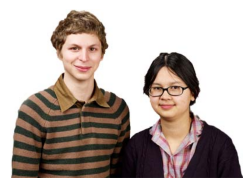

In [11]:
# Example of image containing multiple faces
plt.figure(figsize=(3,3))
plt.imshow(test.iloc[27]['img'])
plt.axis('off')
plt.show()

In [12]:
FACE_SIZE = (100, 100)

class HAARPreprocessor():
    """Preprocessing pipeline built around HAAR feature based cascade classifiers. """
    def __init__(self, path, face_size):
        self.face_size = face_size
        file_path = os.path.join(path, "haarcascade_frontalface_default.xml")
        if not os.path.exists(file_path): 
            if not os.path.exists(path):
                os.mkdir(path)
            self.download_model(file_path)
        
        self.classifier = cv2.CascadeClassifier(file_path)
  
    def download_model(self, path):
        url = "https://raw.githubusercontent.com/opencv/opencv/master/data/"\
            "haarcascades/haarcascade_frontalface_default.xml"
        
        with request.urlopen(url) as r, open(path, 'wb') as f:
            f.write(r.read())
            
    def detect_faces_with_confidence(self, img):
        # Detect faces with confidence estimation
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Start with a high minNeighbors value and gradually decrease
        faces = []
        confidences = []
        
        for min_neighbors in range(10, 2, -1):
            current_faces = self.classifier.detectMultiScale(
                img_gray,
                scaleFactor=1.1,
                minNeighbors=min_neighbors,
                minSize=(25, 25),
                flags=cv2.CASCADE_SCALE_IMAGE
            )
            
            # For each face found at this confidence level
            for face in current_faces:
                # Check if this face overlaps with any previously detected face
                is_new_face = True
                for existing_face in faces:
                    if self._faces_overlap(face, existing_face):
                        is_new_face = False
                        break
                
                # If it's a new face, add it with its confidence score
                if is_new_face:
                    faces.append(face)
                    confidences.append(min_neighbors)
    
        return faces, confidences

    def _faces_overlap(self, face1, face2, overlap_threshold=0.5):
        """Check if two face rectangles overlap significantly."""
        x1, y1, w1, h1 = face1
        x2, y2, w2, h2 = face2
        
        # Calculate intersection area
        x_overlap = max(0, min(x1+w1, x2+w2) - max(x1, x2))
        y_overlap = max(0, min(y1+h1, y2+h2) - max(y1, y2))
        intersection = x_overlap * y_overlap
        
        # Calculate union area
        area1 = w1 * h1
        area2 = w2 * h2
        union = area1 + area2 - intersection
        
        # Calculate IoU (Intersection over Union)
        iou = intersection / union if union > 0 else 0
        
        return iou > overlap_threshold

    def get_highest_confidence_face(self, img):
        """Get the face with highest confidence."""
        faces, confidences = self.detect_faces_with_confidence(img)
        
        if not faces:
            return None
        
        # Get the face with highest confidence
        best_idx = np.argmax(confidences)
        x, y, w, h = faces[best_idx]
        
        return img[y:y+h, x:x+w]
    
    def preprocess(self, data_row):
        face = self.get_highest_confidence_face(data_row['img'])
        
        # if no faces were found (face is None), return NaN image
        if face is None:
            nan_img = np.empty(self.face_size + (3,))
            nan_img[:] = np.nan
            return nan_img
        
        # resize the face
        return cv2.resize(face, self.face_size, interpolation=cv2.INTER_AREA)
            
    def __call__(self, data):
        return np.stack([self.preprocess(row) for _, row in data.iterrows()]).astype(int)



In [13]:
# May take a few minutes.
preprocessor = HAARPreprocessor(path = '../../tmp', face_size=FACE_SIZE)

train_X, train_y = preprocessor(train), train['class'].values
test_X = preprocessor(test)


/var/folders/r9/gttbcddn5yn6mw3sfgy1_7ph0000gn/T/ipykernel_65486/3556036033.py:101: RuntimeWarning: invalid value encountered in cast
  return np.stack([self.preprocess(row) for _, row in data.iterrows()]).astype(int)


**Visualise**

Let's plot a few examples.

In [14]:
def plot_image_sequence(data, n, imgs_per_row=7):
    n_rows = 1 + int(n/(imgs_per_row+1))
    n_cols = min(imgs_per_row, n)

    f,ax = plt.subplots(n_rows,n_cols, figsize=(10*n_cols,10*n_rows))
    for i in range(n):
        if n == 1:
            ax.imshow(data[i])
        elif n_rows > 1:
            ax[int(i/imgs_per_row),int(i%imgs_per_row)].imshow(data[i])
        else:
            ax[int(i%n)].imshow(data[i])
    plt.show()

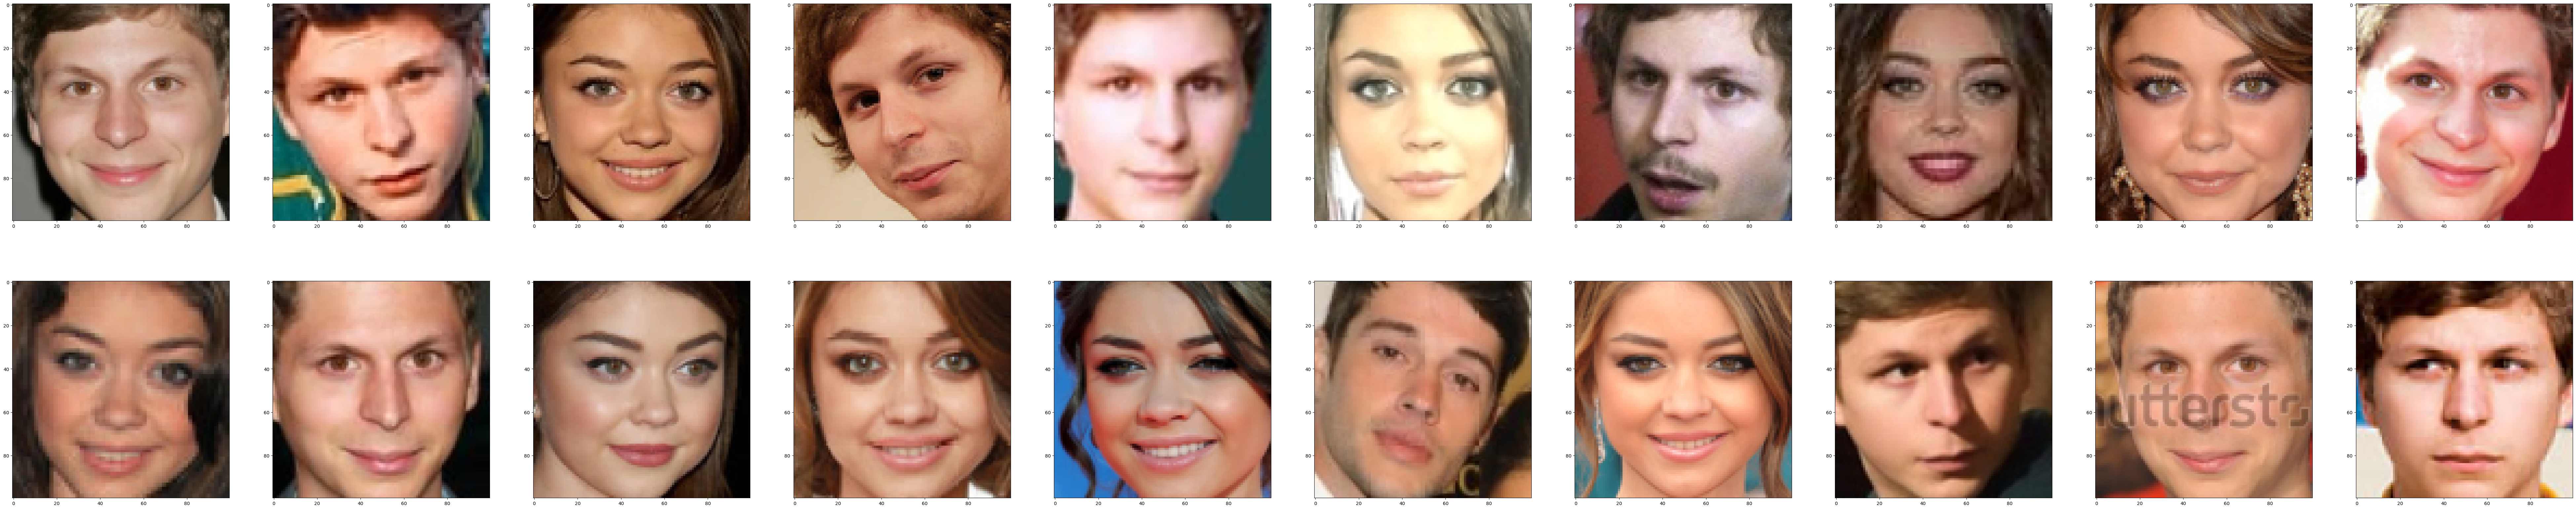

In [15]:
# plot faces of Michael and Sarah

plot_image_sequence(train_X[train_y == 0], n=20, imgs_per_row=10)

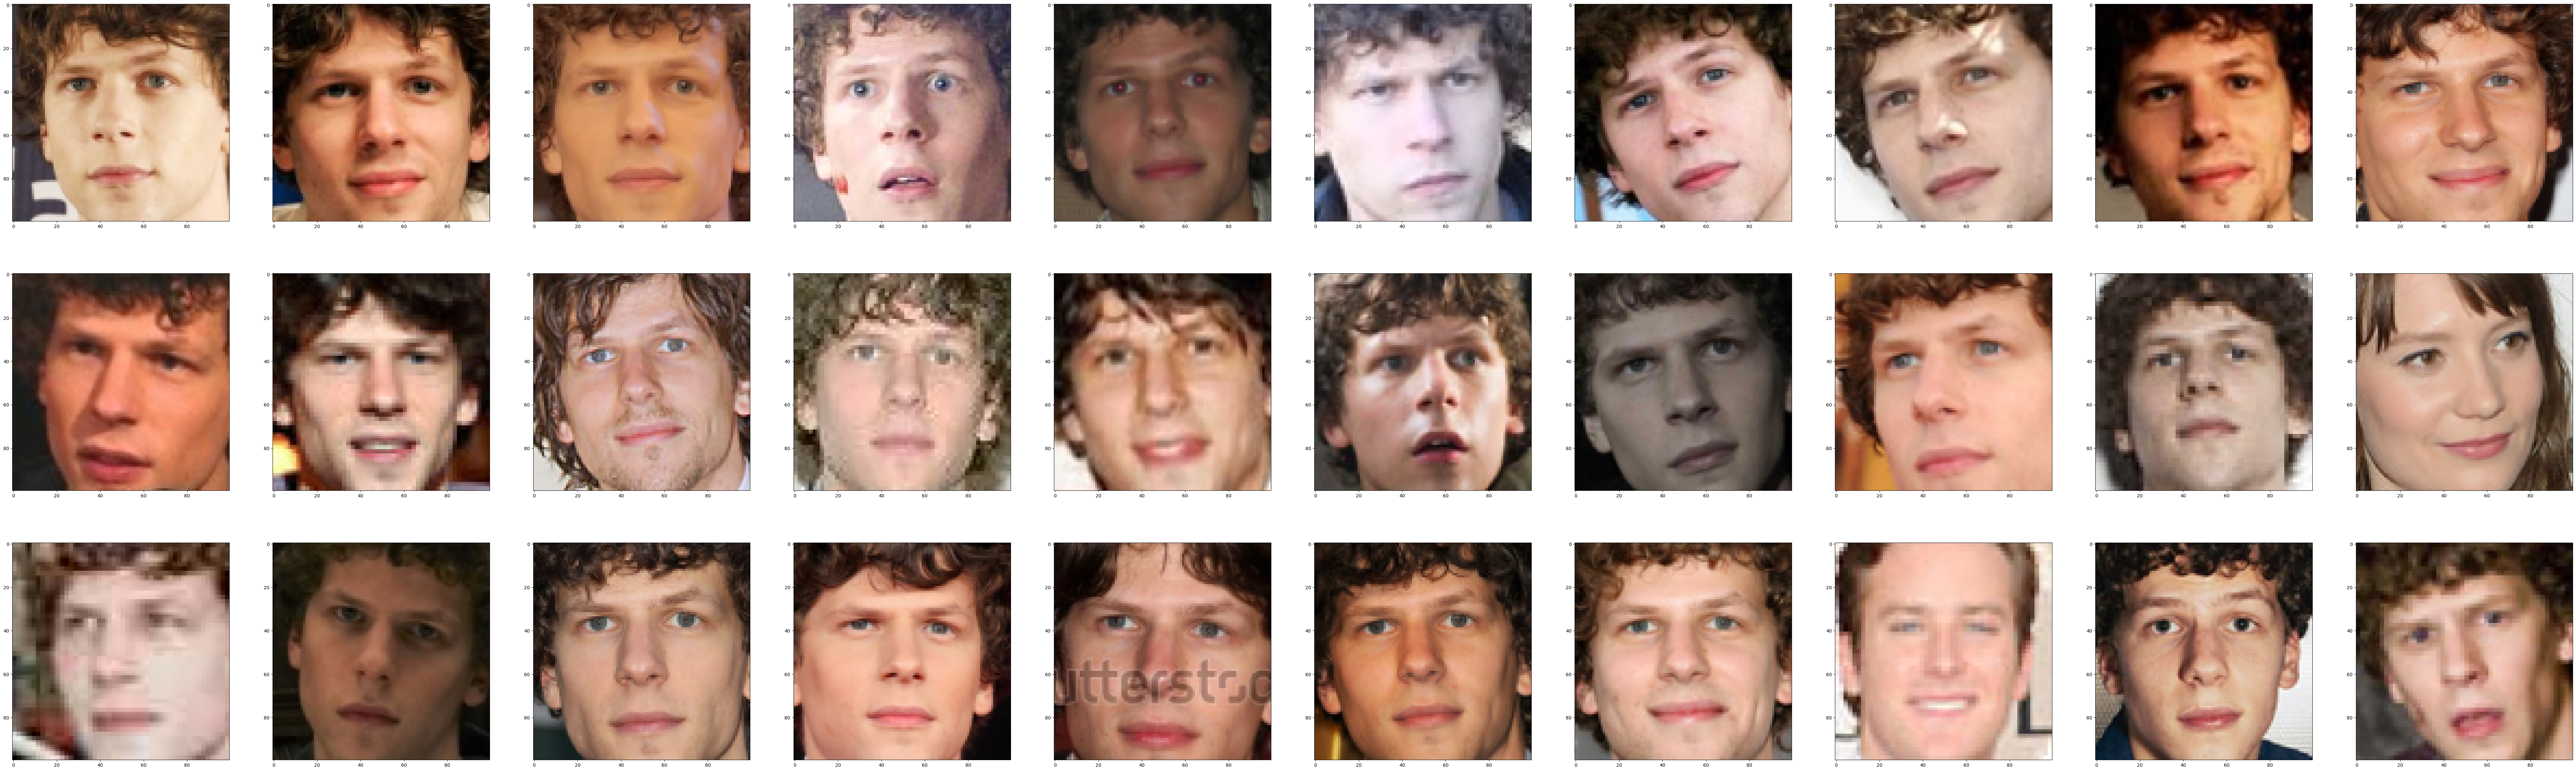

In [16]:
# plot faces of Jesse

plot_image_sequence(train_X[train_y == 1], n=30, imgs_per_row=10)

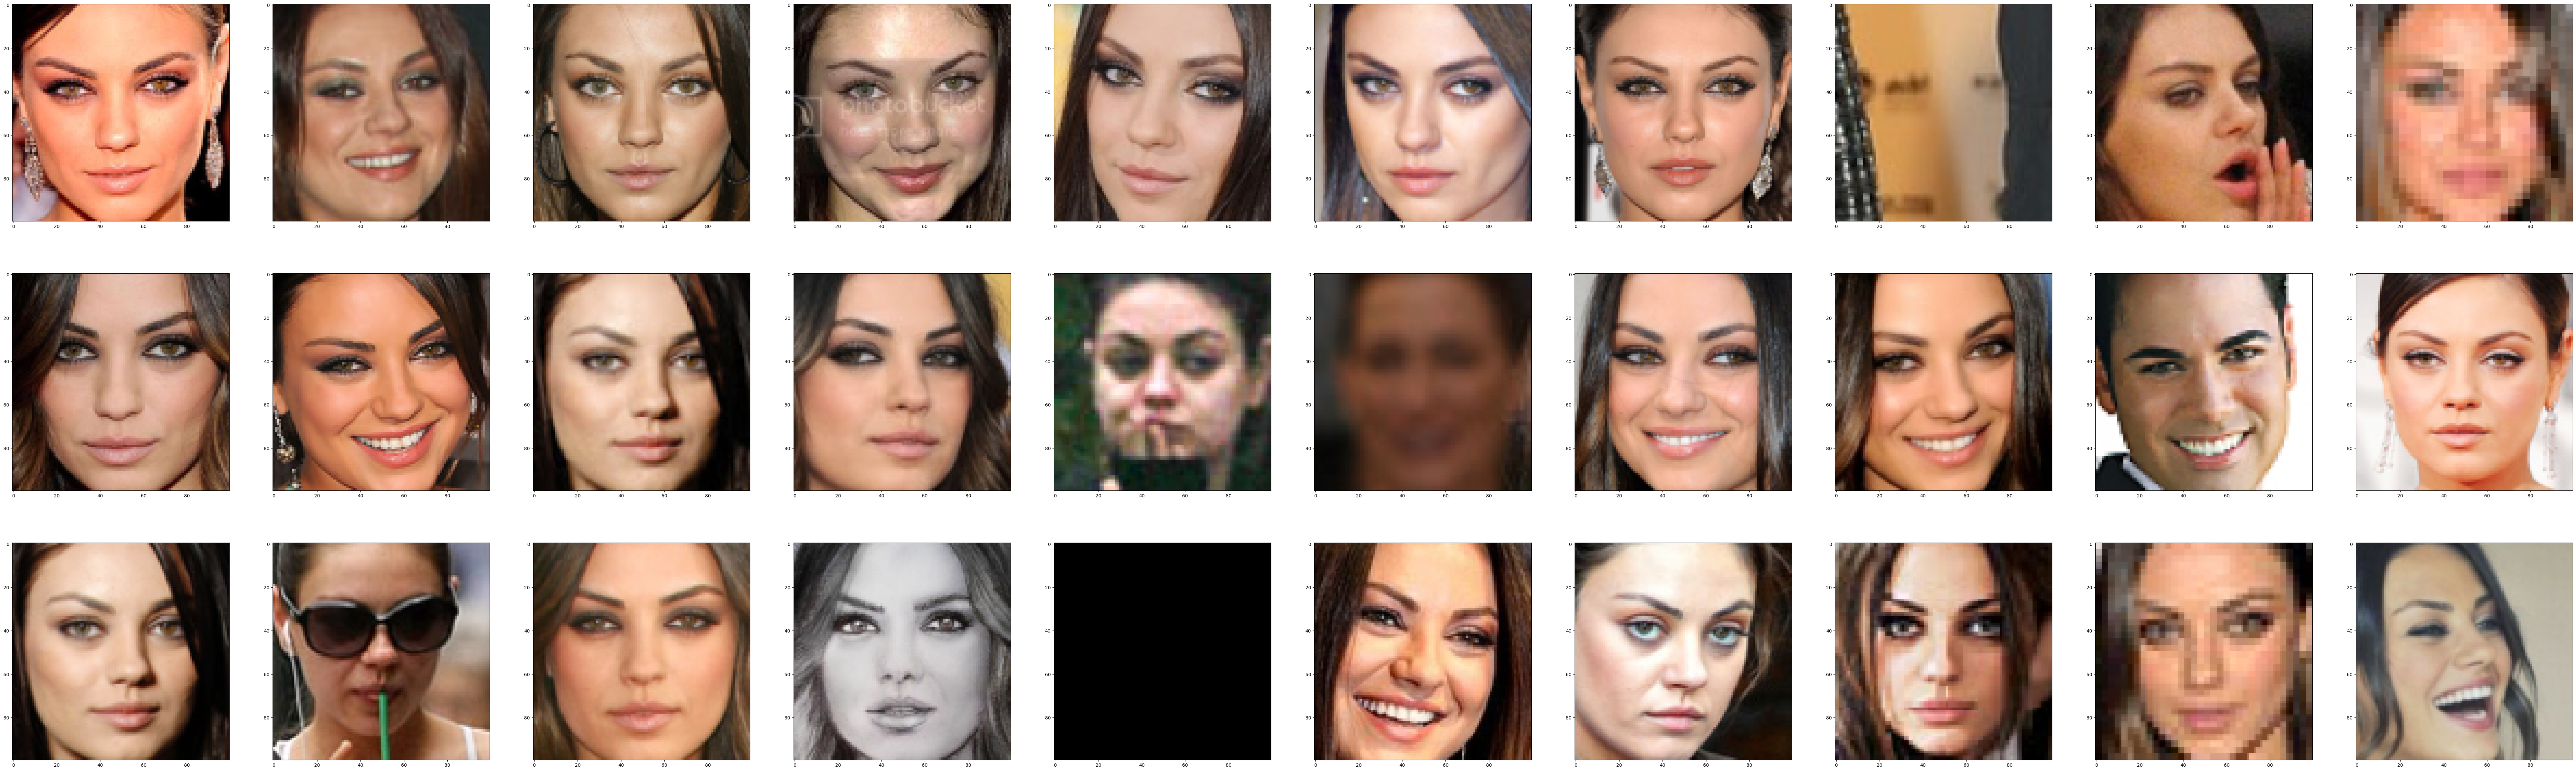

In [17]:
# plot faces of Mila

plot_image_sequence(train_X[train_y == 2], n=30, imgs_per_row=10)

## 0.4. Store Preprocessed data (optional)
<div class="alert alert-block alert-info">
<b>NOTE:</b> You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All". Feel free to use this to store intermediary results.
</div>

Saving the preproccessed data

In [18]:
# prep_path = '/kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#      os.mkdir(prep_path)
    
# np.save(os.path.join(prep_path, 'train_X.npy'), train_X)
# np.save(os.path.join(prep_path, 'train_y.npy'), train_y)
# np.save(os.path.join(prep_path, 'test_X.npy'), test_X)


Loading the preproccessed data

In [19]:
# prep_path = './kaggle/working/prepped_data/'
#  if not os.path.exists(prep_path):
#      os.mkdir(prep_path)
#  train_X = np.load(os.path.join(prep_path, 'train_X.npy'))
#  train_y = np.load(os.path.join(prep_path, 'train_y.npy'))
#  test_X = np.load(os.path.join(prep_path, 'test_X.npy'))

Now we are ready to rock!

# 1. Feature Representations
## 1.0. Example: Identify feature extractor
Our example feature extractor doesn't actually do anything... It just returns the input:
$$
\forall x : f(x) = x.
$$

It does make for a good placeholder and baseclass ;).

In [20]:
class IdentityFeatureExtractor:
    """A simple function that returns the input"""
    
    def transform(self, X):
        return X
    
    def __call__(self, X):
        return self.transform(X)

## 1.1. Baseline 1: HOG feature extractor/Scale Invariant Feature Transform

Within this notebook we will build two types of features to use as a baseline:

    1. Handcrafted features
    2. Features learned from the data

Let's begin with the first type, handcrafted features are features that are designed by humans based on knowledge of the data and are not learned from the data itself by a computer. For example, imagine you are teaching someone how to recognise a cat. You may say soemthing like "Look for pointy ears, whiskers, and a tail." These specific things to look for are handcrafted features - chosen by humans based on knowledge about cats.

Some common exmaples in facial recognition are:

    - Distance between the eyes (pixels)
    - Ratio of nose width to face width
    - Facial landmarks

Here we define a feature extractor that uses Histogram of Oriented Gradients (HOG) to extract features from the images. HOG is an example of a hand-crafted feature extractor, it captures the distribution of intensity gradients (edge directions) in an image. Our faces are 3D and is therefore full of shadows and contours outlining our features (e.g. the shadow where the cheek meets the nose). These shadows and outlines appear in images as lines of changing pixel intensity (gradients). HOG specifically detects these gradients and their orientations, making it effective for facial recognition- by identifying these features- regardless of lighting conditions.

HOG works by dividing the image into small cells, computing the edge orientations in each cell (histogram of gradients), and normalising these histograms to account for changes in illumination, contrast, etc.. HOG is particularly effective for object detection and image classification tasks and can be seen implemented below.

In [21]:
class HOGFeatureExtractor(IdentityFeatureExtractor):
    def __init__(self, **params):
        self.params = {
            'orientations': 9,
            'pixels_per_cell': (12, 12),
            'cells_per_block': (3, 3),
            'block_norm': 'L2-Hys',
            'visualize': False,
            'channel_axis': -1,
            'feature_vector': True
        }
       
        self.params.update(params)
    
    def fit(self, X, y=None):
        """
        Fit method required by scikit-learn transformer interface.
        This is a no-op for HOG features as they don't require fitting.
        """
        return self
        
    def transform(self, X):
        """
        Transform an array of images into HOG features.
        """
        nan_mask = np.isnan(X).any(axis=(1,2,3)) if X.ndim == 4 else np.isnan(X).any(axis=(1,2))
   
        features = []
        
        for i, img in enumerate(X):
            if nan_mask[i]:
                dummy_img = np.zeros_like(X[0])
                dummy_features = hog(dummy_img, **self.params)
                features.append(np.zeros_like(dummy_features))
            else:
                if img.dtype == np.uint8:
                    img = img / 255.0
                
                features.append(hog(img, **self.params))
        
        return np.array(features)

### 1.1.1. t-SNE Plots

Our HOG feature extraction creates a very high-dimensional representation of each face - essentially a long list of numbers (often hundreds or thousands of values). While these features work well for the computer to recognize faces, we as humans can't easily see patterns in such high-dimensional data. Therefore, after extracting HOG features from our facial images, we'll use t-SNE (t-Distributed Stochastic Neighbor Embedding) to visualize these features.

T-SNE works by converting the similarities between data points into probabilities and then tries to preserve these relationships when mapping the data to lower dimensions. Therefore, we will observe a plot where each dot represents a signle face. Dots (faces) closer together will be considered similar in terms of the HOG features, and the farther apart dots will be considered dissimilar. Hence, tight well-seperated clusters represents good recognition ability, whereas overlapping clusters suggests confusion between people. Furthermore, if we observe scattered points with no real grouping this might indicate that our features aren't capturing useful patterns.

Forme des caractéristiques HOG: (320, 900)


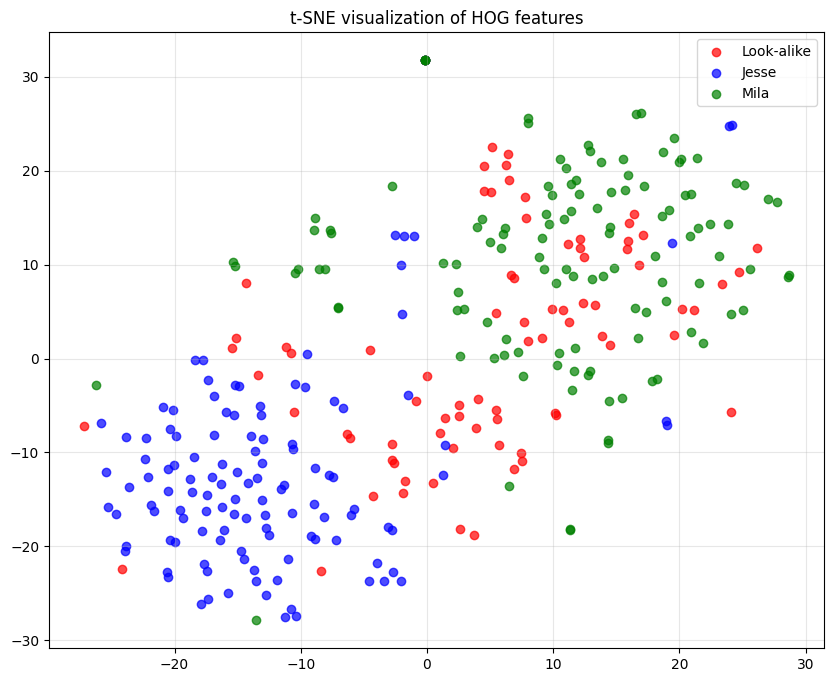

Évaluation de l'extracteur HOG:
Accuracy: 0.9187 ± 0.0527


In [22]:
# Testons notre extracteur HOG
hog_extractor = HOGFeatureExtractor(
    orientations=4,
    pixels_per_cell=(14, 14),
    cells_per_block=(3, 3),
    block_norm='L2-Hys'
)

# Extraire les caractéristiques HOG des images d'entraînement
train_hog_features = hog_extractor.transform(train_X)

print(f"Forme des caractéristiques HOG: {train_hog_features.shape}")

def plot_tsne_2d(features, labels, title="t-SNE visualization of features"):
    """Plot t-SNE visualization of features"""

    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(features)
    
    colors = {0: 'red', 1: 'blue', 2: 'green'}
    label_names = {0: 'Look-alike', 1: 'Jesse', 2: 'Mila'}
    
    plt.figure(figsize=(10, 8))
    for label in np.unique(labels):
        idx = labels == label
        plt.scatter(features_2d[idx, 0], features_2d[idx, 1], 
                   c=colors[label], label=label_names[label], alpha=0.7)
    
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# Visualiser les caractéristiques HOG avec t-SNE
plot_tsne_2d(train_hog_features, train_y, "t-SNE visualization of HOG features")


# Test de performance avec validation croisée
def evaluate_feature_extractor(feature_extractor, X, y, cv=5):
    """Évalue un extracteur de caractéristiques avec un classifieur SVM"""
    # Extraire les caractéristiques
    features = feature_extractor.transform(X)
    
    # Créer un pipeline avec mise à l'échelle et SVM
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(C=10, kernel='rbf', gamma='scale', probability=True, class_weight='balanced', random_state=42))
    ])
    
    # Évaluer avec validation croisée
    scores = cross_val_score(pipeline, features, y, cv=cv, scoring='accuracy')
    
    print(f"Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores

print("Évaluation de l'extracteur HOG:")
hog_scores = evaluate_feature_extractor(hog_extractor, train_X, train_y)

### 1.1.2. Discussion
#### Reflect on the parameters you’ve chosen.

<span style="color:red">Leaving to be updated</span>

#### How does this feature compare to your previous grabbing task in the individual assignment?

In the individual assignment, simple colour thresholding was used in RGB and HSV colour spaces to grab an object from the background. This approach was highly dependant on colour contrast and the surrounding scene. For example, if you had a reflection of light on your object showing as almost white it would be hard to grab the object well, ornif your object had a shadow underneath it it was hard to accurately detect the true edge. In a lot of cases the grabbing only worked effectively if the object had a distinct colour compared to its background and suitable illumination. The task was essentially segmentation using color cues, followed by morphological operations to refine the binary masks.

In contrast, the HOG (Histogram of Oriented Gradients) feature extractor focuses on local edge orientations and gradients, completely ignoring color information. Therefore, in this context the colour (somethign that doesn't solely define an object) becomes unimportant and the technique instead focuses on the shape and structure of objects which are much more discriminative. This makes it much more robust for tasks like facial recognition where consistent edges and contours are more important than color.

#### Did you need specific pre-processing steps before computing these feature descriptors on your images (which ones and why)?
Two main pre-processing steps were applied:

    1- Normalisation of pixel values: 

The hog function expects normalized float inputs for consistent gradient calculation and better feature quality. Therefore, images in the uint8 format (pixel values ranging from 0 to 255) were normalised to the [0, 1] range by dividing by 255.

    2- NaN checking: 

The code checks for the case of an NaN accross each image. If any are present the image is replaces with a dummy, zero-filled image and a zero-values feature vector is returned. This is to ensure that the feature array maintains consistent dimensions and avoids runtime errors during HOG extraction.

#### Did the visualisation show good discriminative and robustness properties?

As mentioned above, we want to observe tight clusters wihtin our t-SNE plot, this indicates good recognition and discriminative abilities. Furthermore, well-seperated clusters are desirable as this suggest good robustness.

<span style="color:red">Leaving this to be updated.</span>

## 1.2. Baseline 2: PCA feature extractor

In this section we will focus on extraction of features learned from the data. This method looks for patterns in the data that are informative and can be used to classify the data, as opposed to pre-set features decided by humans.

We will focus on a specific type of learned feature extracting calles Principle Component Analysis (PCA). When a model considers faces it sees a collection of (lots of) numbers — things like pixel brightness, edges, and textures — which creates a very complex, high-dimensional space that we can’t easily visualise.

PCA (Principal Component Analysis) helps simplify this by finding the p most important patterns in the data — basically, the directions where the faces differ the most.

The following code is a simple PCA feature extractor that uses the PCA implementation from sklearn. It is not a full-featured PCA implementation and is meant for this specific educational/introduction purposes only.

In [23]:
class PCAFeatureExtractor(IdentityFeatureExtractor):
    """Principal Component Analysis (PCA) Feature Extractor."""
    
    def __init__(self, n_components):
        self.n_components = n_components
        self.pca = None
    
    def fit(self, X):
        """Fit PCA on the dataset."""
        self.pca = PCA(n_components=self.n_components)
        self.pca.fit(X)
        return self
    
    def transform(self, X):
        """Transform input data using the trained PCA model."""
        if self.pca is None:
            raise ValueError("PCA model is not fitted yet. Call `fit` first.")
        return self.pca.transform(X)
    
    def inverse_transform(self, X):
        """Reconstruct the original data from the PCA-transformed representation."""
        if self.pca is None:
            raise ValueError("PCA model is not fitted yet. Call `fit` first.")
        return self.pca.inverse_transform(X)
    
    def __call__(self, X):
        return self.transform(X)


### 1.2.1. Eigenface Plots

Eigenfaces are the principal components obtained from PCA when applied to a set of facial images. They represent the most significant features that capture the variations across all faces in the dataset. Here, we will visualize the eigenfaces and how they can be used to reconstruct faces.

The choice of the number of components (p) is crucial. Too few components may lead to loss of important information, while too many can lead to overfitting. We will explore the effect of different numbers of components on the reconstruction of faces by:

1. Visualizing the first few eigenfaces.
2. Reconstructing faces using different numbers of components and comparing them to the original images.
3. Plotting the explained variance ratio to understand how many components are needed to capture most of the variance in the data.
4. Calculating the number of components needed to preserve a certain percentage of variance (e.g., 90% or 95%).

In [24]:
# Map class labels to names for better visualization
name_mapping = {
    0: 'Michael_Cera_and_Sarah',  # Look-alikes
    1: 'Jesse',
    2: 'Mila_Kunis'
}

In [25]:
def create_eigenfaces(train_X, n_components=40):
    """
    Create PCA model for eigenfaces.
    
    Parameters:
    -----------
    train_X : numpy.ndarray
        Training data with shape (n_samples, height, width, channels)
    n_components : int, default=40
        Number of principal components to extract
        
    Returns:
    --------
    pca_extractor : sklearn.decomposition.PCA
        Fitted PCA model
    """
    # Reshape images to 2D array (samples x features)
    X_reshaped = train_X.reshape(train_X.shape[0], -1)
    
    # Create and fit PCA model
    pca_extractor = PCA(n_components=n_components)
    pca_extractor.fit(X_reshaped)
    
    return pca_extractor


def plot_eigenfaces(pca_extractor, FACE_SIZE, n_components_to_plot=9):
    """
    Plot eigenfaces (principal components) from a PCA model.
    
    Parameters:
    -----------
    pca_extractor : sklearn.decomposition.PCA
        Fitted PCA model
    FACE_SIZE : tuple
        Size of the face images (height, width)
    n_components_to_plot : int, default=9
        Number of eigenfaces to plot
    """
    plt.figure(figsize=(15, 8))

    # Plot the mean face first
    mean_face = pca_extractor.mean_.reshape(FACE_SIZE + (3,))
    plt.subplot(3, n_components_to_plot//2 + 1, 1)
    plt.title("Mean Face", fontsize=12)
    plt.imshow(mean_face)
    plt.axis('off')

    # Plot the eigenfaces
    for i in range(n_components_to_plot):
        plt.subplot(3, n_components_to_plot//2 + 1, i + 2)
        # Reshape and normalize the eigenvector for visualization
        eigenface = pca_extractor.components_[i].reshape(FACE_SIZE + (3,))
        eigenface = (eigenface - eigenface.min()) / (eigenface.max() - eigenface.min())
        plt.title(f"Eigenface {i+1}", fontsize=10)
        plt.imshow(eigenface)
        plt.axis('off')

    plt.tight_layout()
    plt.suptitle("Eigenfaces (Principal Components)", fontsize=16, y=0.98)
    plt.subplots_adjust(top=0.9)
    plt.show()


def plot_face_reconstruction(train_X, train_y, name_mapping, FACE_SIZE, n_samples=3, component_levels=[5, 15, 30]):
    """
    Visualize face reconstruction using different numbers of principal components.
    Handles uint8 input data properly.
    
    Parameters:
    -----------
    train_X : numpy.ndarray
        Training data with shape (n_samples, height, width, channels) in uint8 format
    train_y : numpy.ndarray
        Training labels
    name_mapping : dict
        Mapping from class indices to names
    FACE_SIZE : tuple
        Size of the face images (height, width)
    n_samples : int, default=3
        Number of samples to select from each class
    component_levels : list, default=[5, 15, 30]
        List of component counts to use for reconstruction
    """
    plt.figure(figsize=(15, 10))

    # Select some sample faces from each class
    sample_indices = []
    for class_id in range(len(name_mapping)):
        indices = np.where(train_y == class_id)[0]
        if len(indices) >= n_samples:
            sample_indices.extend(np.random.choice(indices, n_samples, replace=False))
        else:
            sample_indices.extend(indices)  # Use all available if less than n_samples

    # Original faces row
    for i, idx in enumerate(sample_indices):
        plt.subplot(4, len(sample_indices), i+1)
        plt.title(f"Original: {name_mapping[train_y[idx]]}", fontsize=8)
        plt.imshow(train_X[idx])
        plt.axis('off')

    # Convert to float32 for processing (preserving the original uint8 data)
    X_float = train_X.astype(np.uint8)
    
    # Reshape data for PCA
    X_reshaped = X_float.reshape(X_float.shape[0], -1)
    
    # Reconstructions with increasing numbers of components
    for row, n_comp in enumerate(component_levels):
        reduced_pca = PCA(n_components=n_comp)
        reduced_features = reduced_pca.fit_transform(X_reshaped)
        reconstructed = reduced_pca.inverse_transform(reduced_features)
        
        for i, idx in enumerate(sample_indices):
            plt.subplot(4, len(sample_indices), (row+1)*len(sample_indices) + i+1)
            rec_img = reconstructed[idx].reshape(FACE_SIZE + (3,))
            
            # Ensure values are in valid range for uint8 and convert back
            rec_img = np.clip(rec_img, 0, 255).astype(np.uint8)
            plt.imshow(rec_img)
            plt.title(f"{n_comp} components", fontsize=8)
            plt.axis('off')

    plt.tight_layout()
    plt.suptitle("Face Reconstruction using PCA", fontsize=16, y=0.98)
    plt.subplots_adjust(top=0.9)
    plt.show()


def plot_variance_explained(pca_extractor):
    """
    Display variance explained by principal components.
    
    Parameters:
    -----------
    pca_extractor : sklearn.decomposition.PCA
        Fitted PCA model
    
    Returns:
    --------
    components_for_90_percent : int
        Number of components needed to preserve 90% of variance
    """
    plt.figure(figsize=(10, 4))
    explained_var = pca_extractor.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)
    components = range(1, len(explained_var) + 1)

    plt.subplot(1, 2, 1)
    plt.bar(components[:20], explained_var[:20], alpha=0.7)
    plt.title("Variance Explained by Each Component")
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(components[:50], cumulative_var[:50], 'o-', markersize=4)
    plt.axhline(y=0.9, color='r', linestyle='--', alpha=0.7)
    plt.axhline(y=0.95, color='g', linestyle='--', alpha=0.7)
    plt.title("Cumulative Explained Variance")
    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.grid(alpha=0.3)
    
    components_for_90_percent = np.where(cumulative_var >= 0.9)[0][0] + 1
    print(f"Number of components needed to preserve 90% of variance: {components_for_90_percent}")
    
    return components_for_90_percent

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [39.103125..222.753125].


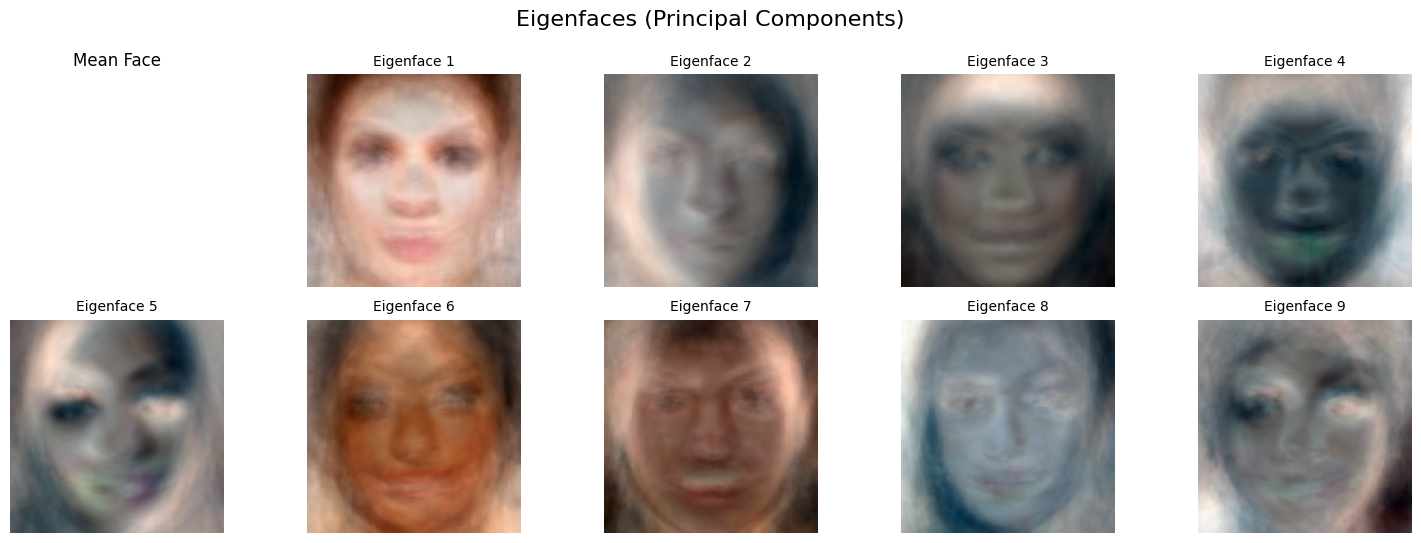

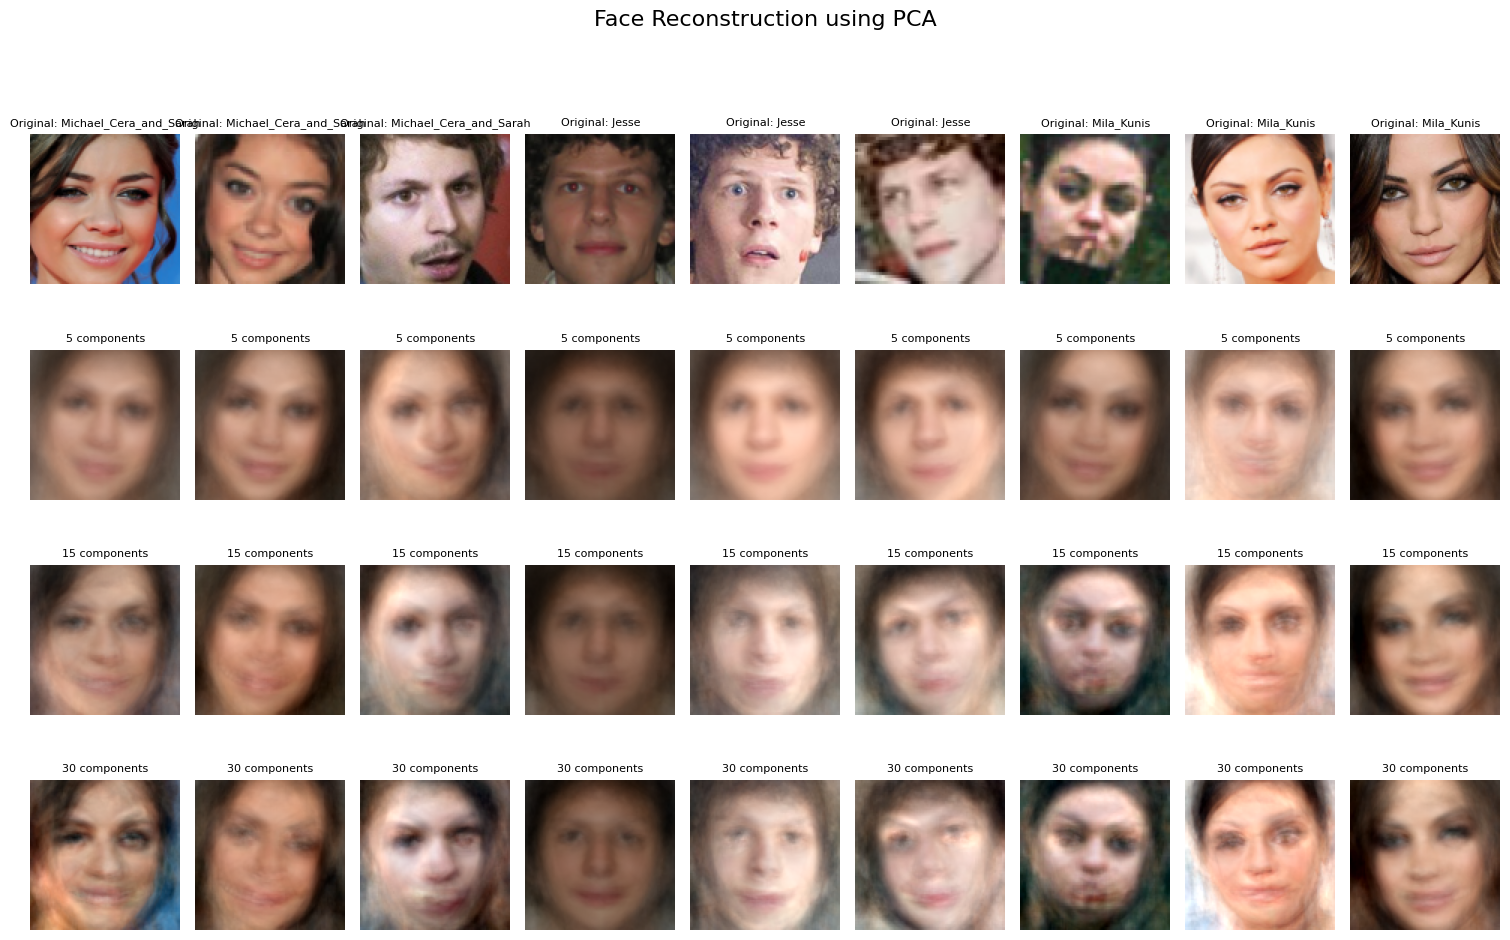

Number of components needed to preserve 90% of variance: 64


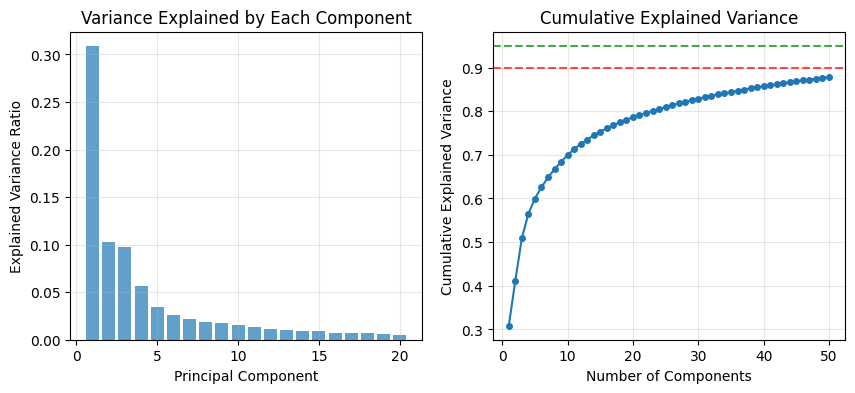

In [26]:
# Define parameters
n_components = 80
n_components_to_plot = 9
n_samples = 3

# Map class labels to names for better visualization
name_mapping = {
    0: 'Michael_Cera_and_Sarah',  # Look-alikes
    1: 'Jesse',
    2: 'Mila_Kunis'
}

new_train_X = train_X.astype(np.uint8)  
# Create and fit PCA model
pca_extractor = create_eigenfaces(new_train_X, n_components=n_components)

# Plot eigenfaces
plot_eigenfaces(pca_extractor, FACE_SIZE, n_components_to_plot)

# Plot face reconstruction
plot_face_reconstruction(new_train_X, train_y, name_mapping, FACE_SIZE, n_samples)

# Plot variance explained
components_for_90_percent = plot_variance_explained(pca_extractor)

### 1.2.2. Feature Space Plots
Here we will visualize the PCA feature space using a scatter plot. This will help us understand how well the PCA features separate the different classes. We will use the PCA features to create a 2D scatter plot, where each point represents a face and is colored according to its class label. We will then plot the centroids of each class in the PCA feature space. These points represent the average PCA features for each class (person) and can help us understand the distribution of the classes (people) in the feature space.

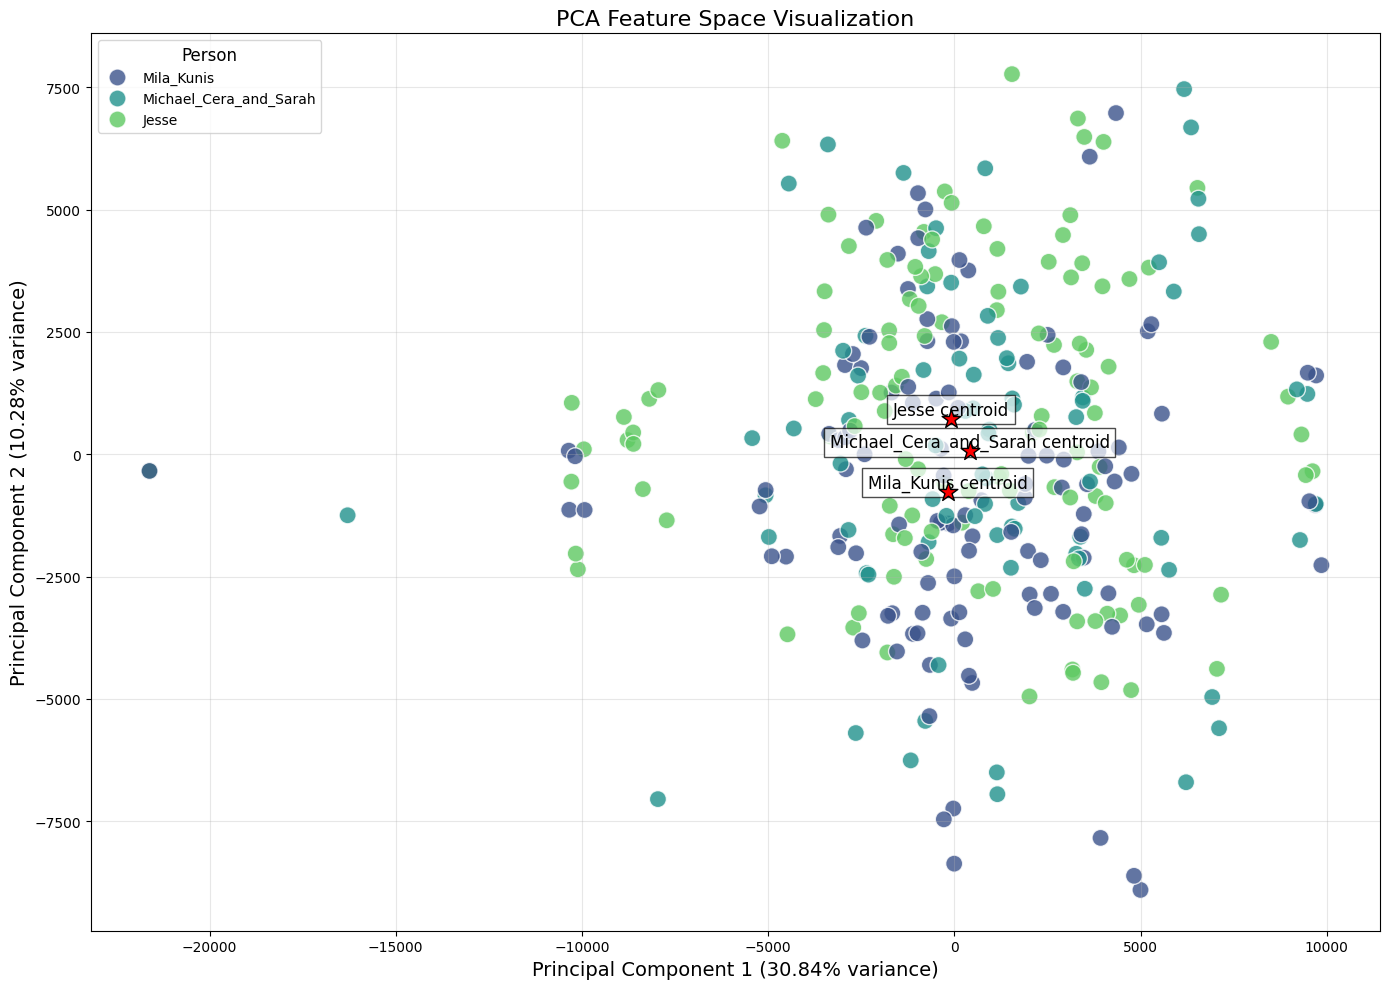

PCA Feature Space Analysis:
Total explained variance in 2D: 41.13%

Mila_Kunis:
  Number of samples: 120
  Centroid: (-182.54, -768.86)
  Spread (std dev): 5458.04, 2968.07
  Distance to Michael_Cera_and_Sarah centroid: 1018.71
  Distance to Jesse centroid: 1501.06

Michael_Cera_and_Sarah:
  Number of samples: 80
  Centroid: (410.95, 59.12)
  Spread (std dev): 5470.82, 3329.85
  Distance to Mila_Kunis centroid: 1018.71
  Distance to Jesse centroid: 837.68

Jesse:
  Number of samples: 120
  Centroid: (-91.43, 729.44)
  Spread (std dev): 5309.39, 2950.38
  Distance to Mila_Kunis centroid: 1501.06
  Distance to Michael_Cera_and_Sarah centroid: 837.68


In [42]:
# Prepare data for visualization (flatten images)
train_X_flat = new_train_X.reshape(train_X.shape[0], -1)

# Apply PCA to reduce to 2 dimensions for visualization
reduced_pca = PCA(n_components=2)
pca_2d = reduced_pca.fit_transform(train_X_flat)

# Create a DataFrame for easier plotting
df_pca = pd.DataFrame({
    'PC1': pca_2d[:, 0],
    'PC2': pca_2d[:, 1],
    'Class': train_y
})


df_pca['Name'] = df_pca['Class'].map(name_mapping)

# Create a more visually appealing plot
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Name',
    data=df_pca,
    palette='viridis',
    s=150,
    alpha=0.8
)

# Add annotations and styling
plt.title('PCA Feature Space Visualization', fontsize=16)
plt.xlabel(f'Principal Component 1 ({reduced_pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=14)
plt.ylabel(f'Principal Component 2 ({reduced_pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=14)
plt.legend(title='Person', title_fontsize=12, fontsize=10)

# Improve plot aesthetics
plt.grid(alpha=0.3)
plt.tight_layout()

# Draw confidence ellipses for each class
for class_id, name in name_mapping.items():
    subset = df_pca[df_pca['Class'] == class_id]
    # Calculate centroid
    centroid_x = subset['PC1'].mean()
    centroid_y = subset['PC2'].mean()
    plt.scatter(centroid_x, centroid_y, s=200, marker='*', color='red', edgecolor='black', zorder=10)
    plt.text(centroid_x, centroid_y, f"{name} centroid", fontsize=12, 
             ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.7))

plt.show()

# Print some metrics about class separation
print("PCA Feature Space Analysis:")
total_var = reduced_pca.explained_variance_ratio_.sum()
print(f"Total explained variance in 2D: {total_var:.2%}")

# Calculate between-class and within-class distances
for class_name in df_pca['Name'].unique():
    class_data = df_pca[df_pca['Name'] == class_name]
    print(f"\n{class_name}:")
    print(f"  Number of samples: {len(class_data)}")
    print(f"  Centroid: ({class_data['PC1'].mean():.2f}, {class_data['PC2'].mean():.2f})")
    print(f"  Spread (std dev): {class_data['PC1'].std():.2f}, {class_data['PC2'].std():.2f}")
    
    # Calculate distances to other classes
    for other_class in df_pca['Name'].unique():
        if other_class != class_name:
            other_data = df_pca[df_pca['Name'] == other_class]
            # Distance between centroids
            dist = ((class_data['PC1'].mean() - other_data['PC1'].mean())**2 + 
                    (class_data['PC2'].mean() - other_data['PC2'].mean())**2)**0.5
            print(f"  Distance to {other_class} centroid: {dist:.2f}")

### 1.2.3. Discussion
#### PCA Implementation
We implemented PCA for feature extraction by fitting it to the provided dataset, and subsequently represented the images in a lower-dimension. PCA computed the covariance matrix of the dataset and its eigenvectors (eigenfaces) and eigenvalues (variance explained by each component). We then visualised the eigenfaces and the reconstructed images for various different p values. We also plotted the cumulative explained variance and the variance explained by each component to find the optimal p, and the 2D PCA vector space to visualize how well PCA separates different classes in a lower-dimensional space.

#### Choice of p and how it influenced performance
The number of components (p) in PCA represents how many principle components will be preserved in the lower dimensional representation. The choise of this value is crucial for feature learning in PCA. You want to choose a value for p which optimises the trade-off between the reconstruction quality and the amount of compression carried out. You want to avoid the following scenarios:
1. Too small a value for p: Leads to loss of possibly important information, resulting in blurry reconstructions and the learning of less discriminative features. 
2. Too large a value for p: Leads to the model learning the noise or unnecessary features as oposed to important, meaningful patterns (e.g. facial features).
To analyse the impact of the choice of the value of p we visualised the reconstructed faces of all three classes for various different p values. It can be observed that the reconstruction improves as we use a higher number of components, we can observe the blurriness in the reconstruction using 5 or 15 components where the reconstructed faces seem to look like a mix of all three identities, possibly indicatin that the model is learnign facial features but not well enough to classify between different people's facial features. This visualisation highlights the impoirtance of this P value and our choice of it. 

To choose an optimum P value we plotted first the variance explained by each components, and it is observed that the first 4 or 5 components hold a significant amount of the variance (information), but there is still a significant amount of variance being held in each component, even up until 20. We then plotted the cumulative explained variance and printed the number of components reuired to 90% of variance (54). Using both this figure and the plot we were able to arrive at our final suitable p value of 55. Analysing and choosing a suitable p value improved our resulst and ensured the model was learning key patterns while reducing dimensionality, improving both computational efficiency and the quality of learned features.

#### Pre-processing steps
The following pre-processing steps were applied before computing the feature descriptors on the images:
1. Reshaping: PCA operates on features vectors as opposed to image matrices, and therefore requires a 2D array of shape (number of samples, number of features). In order to stick to this format our images were flattened from 2D to 1D format. 
2. Centering: PCA works best when the data is centered around zero, as it focuses on the variance of the data. If the data isn't centered, the principal components might capture irrelevant global shifts (illumination, rotation, translation), instead of meaningful variations (facial features). To centre our data we applied mean subtraction (subtracting the mean face from all of the images). Although we did not apply this manually, it is implicitly applied in scikit-learn PCA by not using the whiten=True parameter. 

#### Non-zero eigenvalues
How many non-zero eigenvalues did you have, why? - <span style="color:red">Leaving to be updated</span>

#### Discriminative and robustness properties
To visualise the discriminative and robustness properties of the model we further plotted the 2D PCA feature space. When the model considers faces at faces it sees a collection of (lots of) numbers — things like pixel brightness, edges, and textures — which creates a very complex, high-dimensional space that we can’t easily visualise.

PCA (Principal Component Analysis) helps simplify this by finding the p most important patterns in the data — basically, the directions where the faces differ the most. In a 2D PCA feature space we take the first two components and set them as the X and Y axes.

This could equivelantly be conceptualised as shining a light on a 3D object and looking at its shadow on the wall. You lose some details, but you get a clearer overall, basic picture that you can actually see and interpret. That graph is showing a “shadow” of the original face data, keeping the most meaningful differences. The percentages (30.84% and 10.28%) tell us how much of the original info is kept in each direction. 

This graph can then be used to asses the discriminative and robustness properties of the model.

Discriminative:
* Well-separated color groups = model can tell people apart well
* Mixed/overlapping colors = model gets confused between people

Robustness:
* Tight, compact clusters = model consistently recognizes the same person
* Spread-out clusters = model is inconsistent with recognition
* Distance between centers (centroids) shows how differently the model perceives each person

<span style="color:red">Leaving to be updated</span>



# 2. Evaluation Metrics
## 2.0. Example: Accuracy
As example metric we take the accuracy. Informally, accuracy is the proportion of correct predictions over the total amount of predictions. It is used a lot in classification but it certainly has its disadvantages...

In [28]:
from sklearn.metrics import accuracy_score

In order to better visualize and evaluate our results, we will use the f1-score, confusion matrix and classification_report in order to also observe precision and recall.

In [29]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# 3. Classifiers
## 3.0. Example: The *'not so smart'* classifier
This random classifier is not very complicated. It makes predictions at random, based on the distribution obseved in the training set. **It thus assumes** that the class labels of the test set will be distributed similarly to the training set.

In [30]:
class RandomClassificationModel:
    """Random classifier, draws a random sample based on class distribution observed 
    during training."""
    
    def fit(self, X, y):
        """Adjusts the class ratio instance variable to the one observed in y. 

        Parameters
        ----------
        X : tensor
            Training set
        y : array
            Training set labels

        Returns
        -------
        self : RandomClassificationModel
        """
        
        self.classes, self.class_ratio = np.unique(y, return_counts=True)
        self.class_ratio = self.class_ratio / self.class_ratio.sum()
        return self
        
    def predict(self, X):
        """Samples labels for the input data. 

        Parameters
        ----------
        X : tensor
            dataset
            
        Returns
        -------
        y_star : array
            'Predicted' labels
        """

        np.random.seed(0)
        return np.random.choice(self.classes, size = X.shape[0], p=self.class_ratio)
    
    def __call__(self, X):
        return self.predict(X)
    

## 3.1. Baseline 1: My favorite classifier

#### How did you build this classifier for each of your feature representations? 

#### Do the models hold up when you predict on images of Michael Cera and Sarah Hyland?

### Decision Tree Classifier

In [31]:
class DecisionTreeClassificationModel:
            """Decision Tree classifier with customizable parameters."""
            
            def __init__(self, max_depth=None, criterion='gini', min_samples_split=2):
                """Initialize Decision Tree classifier with specified parameters.
                
                Parameters
                ----------
                max_depth : int or None, default=None
                    The maximum depth of the tree. If None, nodes are expanded until all 
                    leaves are pure or contain less than min_samples_split samples.
                criterion : str, default='gini'
                    Function to measure the quality of a split. Supported criteria are 
                    'gini' for Gini impurity and 'entropy' for information gain.
                min_samples_split : int, default=2
                    The minimum number of samples required to split an internal node.
                """
                self.model = DecisionTreeClassifier(
                    max_depth=max_depth,
                    criterion=criterion,
                    min_samples_split=min_samples_split,
                    random_state=42
                )
            
            def fit(self, X, y):
                """Train the model using the training data.

                Parameters
                ----------
                X : array-like of shape (n_samples, n_features)
                    Training vector.
                y : array-like of shape (n_samples,)
                    Target vector relative to X.

                Returns
                -------
                self : object
                    Returns self.
                """
                self.model.fit(X, y)
                return self
                
            def predict(self, X):
                """Predict class labels for samples in X.

                Parameters
                ----------
                X : array-like of shape (n_samples, n_features)
                    Samples.
                    
                Returns
                -------
                y_pred : array-like of shape (n_samples,)
                    Class labels for samples in X.
                """
                return self.model.predict(X)
            
            def predict_proba(self, X):
                """Return probability estimates for samples in X.
                
                Parameters
                ----------
                X : array-like of shape (n_samples, n_features)
                    Samples.
                    
                Returns
                -------
                y_proba : array-like of shape (n_samples, n_classes)
                    The class probabilities for each sample.
                """
                return self.model.predict_proba(X)
            
            def __call__(self, X):
                return self.predict(X)


### RandomForest Classifier

In [32]:

class RandomForestClassificationModel:
                    """Random Forest classifier with customizable parameters."""
                    
                    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2, criterion='gini'):
                        """Initialize Random Forest classifier with specified parameters.
                        
                        Parameters
                        ----------
                        n_estimators : int, default=100
                            The number of trees in the forest.
                        max_depth : int or None, default=None
                            The maximum depth of the trees. If None, nodes are expanded until all 
                            leaves are pure or contain less than min_samples_split samples.
                        min_samples_split : int, default=2
                            The minimum number of samples required to split an internal node.
                        criterion : str, default='gini'
                            Function to measure the quality of a split. Supported criteria are 
                            'gini' for Gini impurity and 'entropy' for information gain.
                        """
                        self.model = RandomForestClassifier(
                            n_estimators=n_estimators,
                            max_depth=max_depth,
                            min_samples_split=min_samples_split,
                            criterion=criterion,
                            random_state=42
                        )
                    
                    def fit(self, X, y):
                        """Train the model using the training data.

                        Parameters
                        ----------
                        X : array-like of shape (n_samples, n_features)
                            Training vector, where n_samples is the number of samples and
                            n_features is the number of features.
                        y : array-like of shape (n_samples,)
                            Target vector relative to X.

                        Returns
                        -------
                        self : object
                            Returns self.
                        """
                        self.model.fit(X, y)
                        return self
                        
                    def predict(self, X):
                        """Predict class labels for samples in X.

                        Parameters
                        ----------
                        X : array-like of shape (n_samples, n_features)
                            Samples.
                            
                        Returns
                        -------
                        y_pred : array-like of shape (n_samples,)
                            Class labels for samples in X.
                        """
                        return self.model.predict(X)
                    
                    def predict_proba(self, X):
                        """Return probability estimates for samples in X.
                        
                        Parameters
                        ----------
                        X : array-like of shape (n_samples, n_features)
                            Samples.
                            
                        Returns
                        -------
                        y_proba : array-like of shape (n_samples, n_classes)
                            The class probabilities for each sample.
                        """
                        return self.model.predict_proba(X)
                    
                    def __call__(self, X):
                        return self.predict(X)

### SVM classifier

Support Vector Machines (SVMs) aim to find the optimal hyperplane that maximises the margin between classes. SVMs typically excel with small datasets, as they naturally resist overfitting through margin maximisation and model complex, non-linear relationships using the kernel trick. (a trick to implicitly map data into higher-dimensions)

This function below performs a grid search over SVM hyperparameters (including regularisation strength, kernel type, and class weighting) using 5-fold cross-validation to find the optimal configuration. 
It first transforms the input images using the HOG extractor, then evaluates multiple SVM configurations using weighted F1 score as the optimisation metric, ultimately returning the best-performing model

In [33]:


def create_optimized_svm(X_train, y_train, cv=5):
    # Define the parameter grid to search
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1],
        'kernel': ['rbf', 'poly'],
        'class_weight': [None, 'balanced']
    }
    
    # Create just the SVM classifier (not the full pipeline)
    svm = SVC(probability=True, random_state=42)
    
    # Create stratified k-fold to maintain class distribution
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    
    # Create the grid search with just the SVM
    grid_search = GridSearchCV(
        svm,
        param_grid,
        cv=skf,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1
    )
    
    # Get HOG features first (since grid search needs processed features)
    X_train_hog = hog_extractor.transform(X_train)
    
    # Fit the grid search on the HOG features
    grid_search.fit(X_train_hog, y_train)
    
    # Print the best parameters
    print("Best parameters:", grid_search.best_params_)
    print("Best cross-validation score: {:.4f}".format(grid_search.best_score_))
    
    # Return the best SVM model (not the full pipeline)
    return grid_search.best_estimator_

### DNN Classifier

This callback function is a helper function used to visualise the learning curves of the Neural Network. It plots both the training and validation loss and accuracy for each epoch.

In [34]:

# Define some useful functions
class PlotLossAccuracy(keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.i = 0
        self.x = []
        self.acc = []
        self.losses = []
        self.val_losses = []
        self.val_acc = []
        self.logs = []

    def on_epoch_end(self, epoch, logs={}):

        self.logs.append(logs)
        self.x.append(int(self.i))
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.acc.append(logs.get('accuracy'))
        self.val_acc.append(logs.get('val_accuracy'))

        self.i += 1

        clear_output(wait=True)
        plt.figure(figsize=(16, 6))
        plt.plot([1, 2])
        plt.subplot(121)
        plt.plot(self.x, self.losses, label="train loss")
        plt.plot(self.x, self.val_losses, label="validation loss")
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
        plt.ylabel('loss')
        plt.xlabel('epoch')
        plt.title('Model Loss')
        plt.legend()
        plt.subplot(122)
        plt.plot(self.x, self.acc, label="training accuracy")
        plt.plot(self.x, self.val_acc, label="validation accuracy")
        plt.legend()
        plt.ylabel('accuracy')
        plt.xlabel('epoch')
        plt.title('Model Accuracy')
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
        plt.show();


As mentioned previously, such a small training set can very likely lead to overfitting, hence our use of data augmentation. To mitigate overfitting further, we implemented significant regularisation strength in our DNN. We added regularisation via:
1. Dropout

   The addition of dropout layers forces the network to learn redundant representations. Dropout also serves as a form of data augmentation, forcing distributed representations and preventing feature co-adaptation. 
2. L2 regularisation

   L2 regularisation adds weight penalties to the loss function to prevent large weights that may indicate memorisation
3. Batch normalisation

   While dropout randomly zeroes activations and data augmentation varies inputs, BatchNorm standardises the distribution of intermediate features. This forces a more stable learning environment that improves gradient flow and forces the network to learn more robust, generalised representations rather than memorising training examples


In [35]:


plot_callback = PlotLossAccuracy()

class DNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, dropout_rate=0.4, regularization_strength=1e-3, 
                 learning_rate=0.001, batch_size=32, epochs=50, verbose=0, callbacks=None):

        self.dropout_rate = dropout_rate
        self.regularization_strength = regularization_strength
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.verbose = verbose
        self.callbacks = callbacks
        self.model = None
        
    def _create_model(self, input_shape):
        # Create a model that works with feature vectors (like HOG features)
        inputs = keras.layers.Input(shape=(input_shape,))
        
        # Dense layers - no need for Flatten since input is already flattened
        x = Dense(128, activation='relu', kernel_regularizer=l2(self.regularization_strength))(inputs)
        x = BatchNormalization()(x)
        x = Dropout(self.dropout_rate)(x)
        x = Dense(64, activation='relu', kernel_regularizer=l2(self.regularization_strength))(x)
        x = BatchNormalization()(x)
        x = Dropout(self.dropout_rate)(x)
        
        # Output layer
        predictions = Dense(self.n_classes_, activation='softmax')(x)
        
        # Create the model
        model = keras.models.Model(inputs=inputs, outputs=predictions)
        
        # Optimizer
        opt = keras.optimizers.Adam(learning_rate=self.learning_rate)
        
        # Compile the model
        model.compile(optimizer=opt,
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
        
        return model
    
    def fit(self, X, y):
        # Store the number of classes
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        
        # Create the model - X is already a feature vector (HOG features)
        self.model = self._create_model(X.shape[1])
        
        # Prepare validation data
        validation_data = None
        if hasattr(self, 'X_validation') and hasattr(self, 'y_validation'):
            validation_data = (self.X_validation, self.y_validation)
        
        # Train the model
        self.model.fit(
            X, y,
            batch_size=self.batch_size,
            epochs=self.epochs,
            verbose=self.verbose,
            callbacks=self.callbacks,
            validation_data=validation_data,
            validation_split=0.2 if validation_data is None else 0.0  # Use validation_split if no explicit validation data
        )
        
        return self
        
    # Add a method to set validation data
    def set_validation_data(self, X_validation, y_validation):
        self.X_validation = X_validation
        self.y_validation = y_validation
        return self
    
    def predict(self, X):
        # Get predictions - X is already a feature vector
        predictions = self.model.predict(X, verbose=0)
        return np.argmax(predictions, axis=1)
    
    def predict_proba(self, X):
        # Get probability predictions - X is already a feature vector
        return self.model.predict(X, verbose=0)

When training DNNs, implementing proper validation techniques is absolutely critical, especially with limited data. Our choice of k-fold cross-validation over simple hold-out validation can be justified for many reasons. 

1. Maximise the use of our limited training data. 
   With only 320 labelled images after augmentation, k-fold cross-validation allowed the use of (k-1)/k of our data for training in each fold, rather than permanently setting aside a portion as a validation set
2. Reduce split bias
   Having such a small training set leaves us vunerable to "unlucky" train/test splits where important examples may end up only in the test set. K-fold validation mitigates this by ensuring every example serves as both training and validation data across different folds.

Despite all mitigation techniques, we can see in the pipeline below (and especially in kaggle submissions) our DNN classifier still suffered from severe overfitting. There are a few possible reasons for this:
1. Data limitation

   Typically DNNs require thousands of samples. It could be possible 320 training samples simply wasn't enough. 
2. Domain shift 

   While unlikely, it is possible the competition test data contained variations not represented in the given training data. Eg: lighting conditions, facial expressions, image quality
3. Model architecture

   Its possible different model architectures could've improved performance, such as Multi-Layer perception networks with skip connections. If I had more time, this would be an area I would like to explore further. 

# 4. Experiments
<div class="alert alert-block alert-info"> <b>NOTE:</b> Do <i>NOT</i> use this section to keep track of every little change you make in your code! Instead, highlight the most important findings and the major (best) pipelines that you've discovered.  
</div>
<br>

## 4.0. Example: basic pipeline
The basic pipeline takes any input and samples a label based on the class label distribution of the training set. As expected the performance is very poor, predicting approximately 1/4 correctly on the training set. There is a lot of room for improvement but this is left to you ;). 

The pipeline below was designed to run all classifiers with both HOG and PCA features, and then provide a clear overview of each classifier's performance.

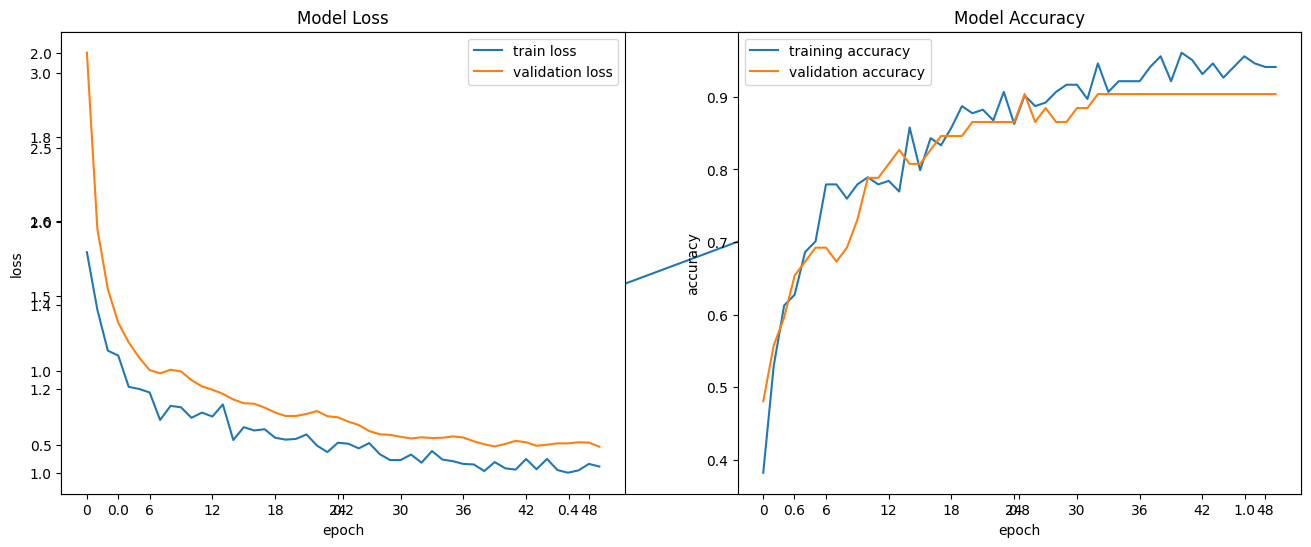

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9306 - loss: 0.3764 - val_accuracy: 0.9038 - val_loss: 0.4884
Results comparing HOG and PCA feature extractors with different classifiers:
   Feature Extractor           Classifier     Val Accuracy           Val F1  \
0                HOG        Decision Tree  0.6937 ± 0.0606  0.6943 ± 0.0564   
1                HOG        Random Forest  0.8125 ± 0.0419  0.7913 ± 0.0554   
2                HOG                  SVM  0.8656 ± 0.0756  0.8635 ± 0.0785   
3                HOG                  KNN  0.8250 ± 0.0643  0.8221 ± 0.0670   
4                HOG  Logistic Regression  0.8469 ± 0.0580  0.8439 ± 0.0585   
5                HOG                  DNN  0.8156 ± 0.0829  0.8099 ± 0.0852   
6                HOG        Optimized SVM  0.9156 ± 0.0581  0.9155 ± 0.0581   
7                HOG             SVM_step  0.9187 ± 0.0536  0.9183 ± 0.0540   
8                PCA        Decision Tree  0.6750 ± 0.0488  0.6701 ± 0.0486   
9                PC

In [ ]:
train_X_reshaped = train_X.reshape(train_X.shape[0], -1)

hog_extractor = HOGFeatureExtractor(
    orientations=5,
    pixels_per_cell=(14, 14),
    cells_per_block=(3, 3),
    block_norm='L2-Hys'
)

# List of classifiers to try
classifiers = [
    ('Decision Tree', DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)),
    ('SVM', SVC(kernel='rbf', probability=True, random_state=42)),
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('DNN', DNNClassifier(epochs=50, batch_size=32, verbose=1, callbacks=[plot_callback])),
    ('Optimized SVM', SVC(C=10, kernel='rbf', gamma='scale', probability=True, class_weight='balanced', random_state=42)),
    ('SVM_step', create_optimized_svm(train_X, train_y))
]

# Create results for both feature extractors
results = []

# First, run with HOG features
for name, clf in classifiers:
    pipeline = Pipeline([
        ('hog', hog_extractor),  # Use HOG features
        ('classifier', clf)
    ])
    
    cv_result = cross_validate(
        pipeline, train_X, train_y, 
        cv=5, 
        scoring=['accuracy', 'f1_weighted'],
        return_train_score=True
    )
    
    results.append({
        'Feature Extractor': 'HOG',
        'Classifier': name,
        'Val Accuracy': f"{cv_result['test_accuracy'].mean():.4f} ± {cv_result['test_accuracy'].std():.4f}",
        'Val F1': f"{cv_result['test_f1_weighted'].mean():.4f} ± {cv_result['test_f1_weighted'].std():.4f}",
        'Train Accuracy': f"{cv_result['train_accuracy'].mean():.4f} ± {cv_result['train_accuracy'].std():.4f}"
    })

# Then, run with PCA features for comparison
n_components = 64
for name, clf in classifiers:
    pipeline = Pipeline([
        ('pca', PCA(n_components=n_components)),  # Use PCA features
        ('classifier', clf)
    ])
    
    cv_result = cross_validate(
        pipeline, train_X_reshaped, train_y, 
        cv=5, 
        scoring=['accuracy', 'f1_weighted'],
        return_train_score=True
    )
    
    results.append({
        'Feature Extractor': 'PCA',
        'Classifier': name,
        'Val Accuracy': f"{cv_result['test_accuracy'].mean():.4f} ± {cv_result['test_accuracy'].std():.4f}",
        'Val F1': f"{cv_result['test_f1_weighted'].mean():.4f} ± {cv_result['test_f1_weighted'].std():.4f}",
        'Train Accuracy': f"{cv_result['train_accuracy'].mean():.4f} ± {cv_result['train_accuracy'].std():.4f}"
    })

# Display results
results_df = pd.DataFrame(results)
print("Results comparing HOG and PCA feature extractors with different classifiers:")
print(results_df)

# Optionally, create a more readable comparison
pivot_df = results_df.pivot(index='Classifier', columns='Feature Extractor', values='Val Accuracy')
print("\nValidation Accuracy Comparison (HOG vs PCA):")
print(pivot_df)

Can comment on overfitting of the DNN model

### Best pipeline for submission

In [37]:

pipeline = Pipeline([
        ('hog', hog_extractor),  # Use HOG features
        ('SVM_step', create_optimized_svm(train_X, train_y))
    ])

# Perform cross-validation
cv_result = cross_validate(
    pipeline, train_X, train_y, 
    cv=5, 
    scoring=['accuracy', 'f1_weighted'],
    return_train_score=True
)

print("Cross-validation results:")
print(f"Validation Accuracy: {cv_result['test_accuracy'].mean():.4f} ± {cv_result['test_accuracy'].std():.4f}")
print(f"Validation F1: {cv_result['test_f1_weighted'].mean():.4f} ± {cv_result['test_f1_weighted'].std():.4f}")
print(f"Training Accuracy: {cv_result['train_accuracy'].mean():.4f} ± {cv_result['train_accuracy'].std():.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(train_y, pipeline.predict(train_X))}")
print(f"Classification Report:\n{classification_report(train_y, pipeline.predict(train_X))}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best parameters: {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation score: 0.9119
Cross-validation results:
Validation Accuracy: 0.9187 ± 0.0536
Validation F1: 0.9183 ± 0.0540
Training Accuracy: 0.9875 ± 0.0029
Confusion Matrix:
[[ 78   0   2]
 [  0 118   2]
 [  0   0 120]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        80
           1       1.00      0.98      0.99       120
           2       0.97      1.00      0.98       120

    accuracy                           0.99       320
   macro avg       0.99      0.99      0.99       320
weighted avg       0.99      0.99      0.99       320



With the HOG and the SVM, we obtain some good results for training and cross-validation as can be seen above with the accuracy and the F1-Score, but also the confusion matrix that indicates 2 mistakes each for class 0 and 1 that were misidentified as class 2. Nevertheless, in the final submission, our results aren't as good, so we suspect there's still quite a lot of overfitting.

In [38]:
# Fit the pipeline on the training data
pipeline.fit(train_X, train_y)

# Now, prepare your test data the same way you did with training data
test_X_reshaped = test_X.reshape(test_X.shape[0], -1)  # Flatten all but first dimension

# Make predictions on the test set
test_y_star = pipeline.predict(test_X)

### Our journey to reach our best results so far and some comments:

In our first attempts locally, we had perfect or near perfect scores for training. At that point, we had tried the PCA combined with a few classifiers, a Decision Tree, Random Forest and SVM. After our first submission where our results were very low (0.49), we realized there was too much overfitting in our results, and also that we had a problem with the implementation of the PCA on Kaggle. We then started using the HOG feature extractor which gave us slightly better results.

We then decided to improve the HAAR Preprocessor which made the execution time much longer, but allowed us to get much better results. We also decided to apply some basic data augmentation in order to double the size of our dataset. This is another reason we decided to stick with the HOG, as the PCA doesn't handle the Data Augmentation techniques such as rotation as well as HOG. We started using Neural Networks starting with an MLP, a CNN and finally a Basic Transformer which allowed us to get the best results so far reaching 0.8.

In order to get better results, we used cross-validation in order to evaluate the results before submission and evaluate more different models faster and make the comparison easier.

We still weren’t satisfied with our results so we tried to fine-tune our hyper parameters. We went back to an SVM with which we hoped we would avoid the overfitting, and once it was fine-tuned and combined with a HOG, it gave us our best results yet of 0.82. We couldn’t keep improving our results with classifiers alone, we had to improve our feature extractors. Our theory was that combining a HOG and a good PCA would allow us to have much better results. We tried to pinpoint the reason our PCA wasn’t performing as well as it did locally (but unsuccessfully).

Overall, our experimentations consisted of evaluating different feature extractors and classifiers from the ones we have studied, trying the simplest ones and then going for the more complex ones. Finally, we tried to fine-tune our hyper-parameters by trying different values. In theory, we would still like to try a well-working PCA we think would make our results much better.

# 5. Publishing best results

### First we can visualise some of the results for submission

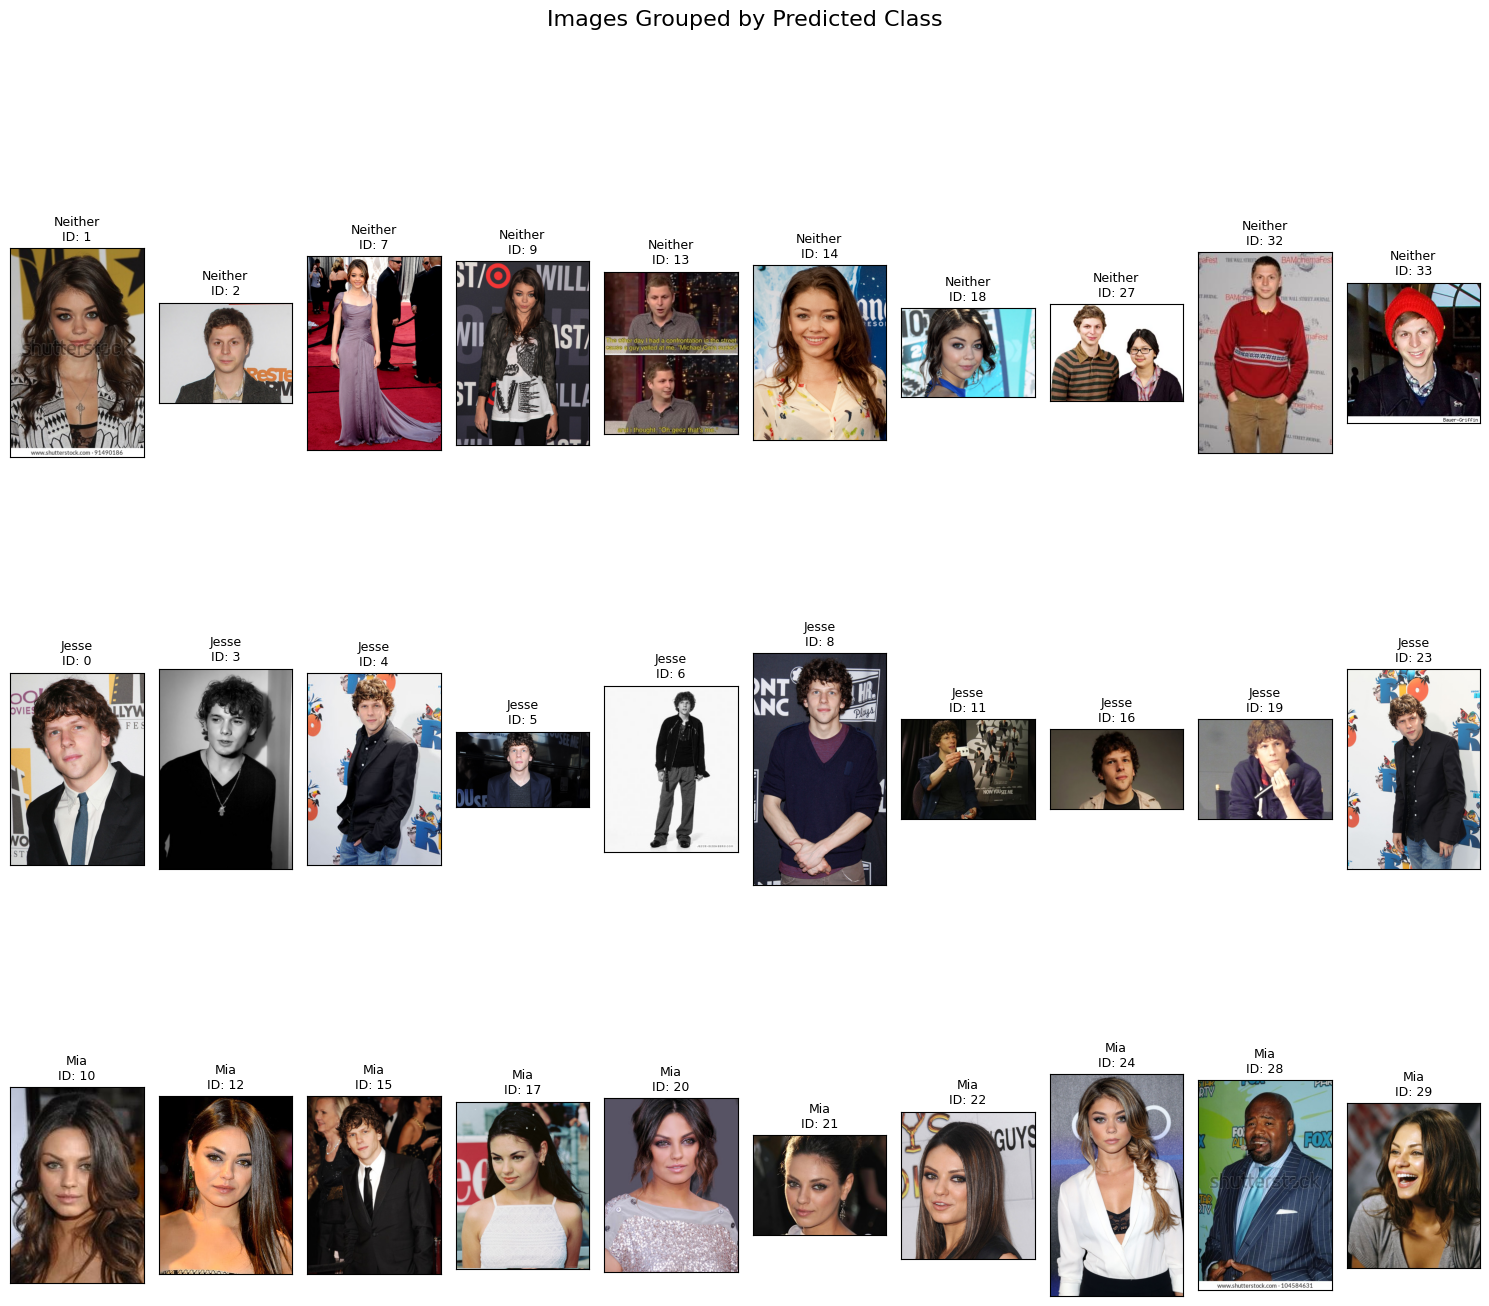

Prediction Summary:
Neither: 681 images (37.5%)
Jesse: 540 images (29.7%)
Mia: 595 images (32.8%)


In [ ]:


def visualize_predictions_by_class(test_data, predictions, num_per_class=10, figsize=(15, 15), class_names=None):
    """
    Visualize test images organized by their predicted classes.
    
    Parameters:
    -----------
    test_data : DataFrame
        DataFrame containing the test images
    predictions : array-like
        Predicted classes for the test images
    num_per_class : int, optional
        Number of images to display per class (default: 10)
    figsize : tuple, optional
        Figure size (default: (15, 15))
    class_names : dict, optional
        Dictionary mapping class indices to class names (default: None)
    """
    # Convert predictions to numpy array if it's not already
    predictions = np.array(predictions)
    
    # Get unique classes
    unique_classes = np.unique(predictions)
    
    # Create a DataFrame with test data and predictions for easier manipulation
    combined_data = pd.DataFrame({
        'image_id': test_data.index,
        'prediction': predictions
    })
    
    # Define class names if not provided
    if class_names is None:
        class_names = {i: f"Class {i}" for i in unique_classes}
    
    # Calculate grid dimensions
    total_rows = len(unique_classes)
    cols = min(num_per_class, max([sum(predictions == c) for c in unique_classes]))
    
    # Create figure with subplots for each class
    fig, axes = plt.subplots(total_rows, cols, figsize=figsize)
    
    # Handle the case where there's only one class
    if total_rows == 1:
        axes = [axes]
    
    # For each class
    for class_idx, class_label in enumerate(unique_classes):
        # Get indices of images predicted as this class
        class_indices = combined_data[combined_data['prediction'] == class_label]['image_id'].values
        
        # Limit to the requested number per class
        display_count = min(num_per_class, len(class_indices))
        
        # Display images for this class
        for i in range(cols):
            ax = axes[class_idx][i] if cols > 1 else axes[class_idx]
            
            if i < display_count:
                # Get the image
                img_idx = class_indices[i]
                img = np.array(test_data.loc[img_idx, 'img'])
                
                # Display image
                ax.imshow(img)
                
                # Set title with class name and image ID
                class_name = class_names[class_label]
                ax.set_title(f"{class_name}\nID: {img_idx}", fontsize=9)
                
                # Remove axis ticks
                ax.set_xticks([])
                ax.set_yticks([])
            else:
                # Hide unused subplots
                ax.axis('off')
    
    # Add a main title
    plt.suptitle("Images Grouped by Predicted Class", fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for suptitle
    plt.show()
    
    # Print summary statistics
    print("Prediction Summary:")
    for class_label in unique_classes:
        count = sum(predictions == class_label)
        percentage = (count / len(predictions)) * 100
        class_name = class_names[class_label]
        print(f"{class_name}: {count} images ({percentage:.1f}%)")


class_names = {0: "Neither", 1: "Jesse", 2: "Mia"}

# Visualize 10 images per predicted class
visualize_predictions_by_class(test, test_y_star, num_per_class=10, class_names=class_names)

We notice more mistakes with Class 2 that is Mia. This happens to confirm the mistakes found during training where Class 0 and 1 happened to be misidentified as Class 2.

### Save to .csv for submission

In [40]:
submission = test.copy().drop('img', axis = 1)
submission['class'] = test_y_star

submission.head(20)

,class
id,
0,1
1,0
2,0
3,1
4,1
5,1
6,1
7,0
8,1


In [41]:
submission.to_csv('submission.csv')

# 6. Discussion


In summary we contributed and learned the following: 



What We Learned About Feature Representations (HOG vs. PCA)

In the context of this project, our team set out to explore the impact of different feature
representations on face classification performance. To prepare a hands-on tutorial for
students attending ECCV 2025, we wanted to not only benchmark techniques, but also
make them easy to understand, reproduce, and build upon.
We focused on two classical approaches to feature extraction: Histogram of Oriented
Gradients (HOG) and Principal Component Analysis (PCA). These were tested with several
common classifiers including SVMs, Decision Trees, Random Forests, KNN, Logistic
Regression and Deep Neural Networks Classifiers (MLP, CNN and Transformers).

1. Understanding the Representations

Before diving into numbers, let’s quickly explain what HOG and PCA are doing with an
intuitive example.
HOG is like a “texture reader.” Imagine trying to recognize someone by feeling the ridges
and grooves of their face blindfolded. HOG captures these local edge directions—where
things like the jawline curves or the eyebrow arches. It transforms an image into a grid of
local gradient patterns, keeping details about shapes and contours.
PCA, on the other hand, is like taking a big photo album of faces and trying to summarize
it into a few “average” faces (called eigenfaces). It keeps the directions in the data that vary
the most. But here's the catch: not all variation is useful. For example, a change in lighting
or background might affect pixel intensities more than the actual identity of the person—
and PCA will prioritize that variance.

2. What the Results Tell Us

We applied both HOG and PCA features to the same dataset and ran multiple classifiers.
Below are the most notable results:
With HOG features, performance was consistently high. For example, a SVM with RBF
kernel achieved a validation accuracy of 95.63% ± 2.50%, and a similar F1-score. Even
simpler models like Logistic Regression reached 90% accuracy, which is impressive given
the complexity of face recognition.
In contrast, PCA features led to poor results across all classifiers. The best model using
PCA, a Random Forest, achieved only 46.88% ± 11.65% accuracy, and most others hovered
around 30%. For example, a Decision Tree with PCA gave just 38.75% accuracy and an F1-
score below 0.27, compared to 0.75+ when using HOG.
Conclusion: HOG was clearly the better choice for this task. The handcrafted local features
were more informative and reliable for distinguishing facial identities.

3. Why Did HOG Work Better?

In face recognition tasks, small local details matter a lot—like the shape of the eyes, the
width of the nose, or the outline of the lips. HOG is designed to capture exactly that. It's
relatively robust to lighting changes, since it looks at how gradients change rather than at
raw pixel values (which is also the main difference with the color-based grabbing detection
that we mentioned earlier in the HOG feature extractor part ).
On the flip side, PCA doesn't know which details are important. It compresses the image
based on overall variance, and that includes things like shadows, brightness, or
background clutter, which don’t help with identifying people. This explains why models
using PCA were not able to learn meaningful distinctions.
Think of it like this:
HOG is like giving your model glasses that focus on the outlines and features of faces.
PCA is more like giving it blurry glasses that notice general brightness and shape, but miss
the details that make each face unique.

4. What Could Be Improved with More Time?

If we had more time or computing resources, we would explore the following:
Trying to use SIFT- The powerful Scale Invariant Feature Transform (SIFT), for example, is
well-known for its robustness to object rotation and scale variations (which is the main
difference with HOG feature extractors that lack of efficiency for scaling images), but this
robustness comes at a high computational cost.
Combining methods – We could apply PCA after HOG to compress the HOG features while
retaining key local information.

Another problem we encountered with PCA that we haven't managed to solve is the fact that we get different results when executing our notebook locally compared to running it on Kaggle. With more time, we would like to figure out the origin of this issue. Indeed, we would get great results locally, with around 28 components explaining 90% of the components and giving us good results when used with a classifier. On Kaggle, PCA performed very poorly which made us choose HOG that was more reliable and adapted to a dataset where we used Augmented Data.

5. Key values for Students

Feature representation matters a lot more than we tought at first. The classifier is very important, but without a good feature extractor, it can't hope to provide good results. Even a simple model with good features (HOG + Logistic Regression) outperformed complex ones with bad features (PCA + SVM). (It is important to note that the reason for bad features is the problem we had already mentioned with the PCA on Kaggle)

Handcrafted features like HOG are still relevant, especially when deep learning is not
available.
Dimensionality reduction like PCA is useful, but it should be applied with care—it’s better
for compression or visualization than for recognition in this case.

6. Final Words (for our ECCV tutorial audience)

This small-scale competition showed us a very real truth in computer vision: what you feed
your model matters. Before choosing the biggest model or the most advanced technique,
take time to think about the data and how it’s being represented. We had big improvement simply by increasing the size or our dataset and improving the HAAR Preprocessing that allowed for better face detection. We also learned the importance of experimenting and trial and error in Computer Vision, that is a task that takes much more time than we thought.
We hope this experiment helps demystify these foundational tools. Understanding their
strengths and limitations is key to becoming a thoughtful and effective computer vision
practitioner.

# Contributions Section


### Stephen Haskins (r1066163)
- Data augmentation & discussion
- Improved HAAR & discussion
- DNN classifier experimentation & discussion
- Pipeline implementation & classifier comparison
- Pipeline Parameter fine tuning

### Hamza El Haddad (r1066163)
- PCA implementation
- First Classifier Implementations and results
- First Submission tests with PCA/HOG and Decision Tree, SVM and Random Forest
- DNN classifier experimentation : MLP, CNN and Transformer to improve results
- Pipeline and results discussion

### Bevin (r1066641)
- PCA & HOG discussion

### Sami (r1065787)
- HOG implementation and t-SNE plots
- Research on fixing PCA on Kaggle

### Kenzo (r1066169)
- Final Discussion